# Forecasting Electricity Capacity and Regional Energy Transitions in Canada

## Background
Electricity system transition analysis requires methods that are empirically robust and policy interpretable. Transition scholarship shows that pathways evolve unevenly across jurisdictions because of institutional design, infrastructure lock-in, and technology diffusion dynamics (Markard, Raven and Truffer, 2012; Sovacool, 2016). Forecast evaluation literature also emphasizes strict temporal validation and transparent error reporting when models are used for planning decisions (Hyndman and Koehler, 2006).

For Canada, these requirements are especially relevant because provinces and territories have structurally different generation portfolios and climate-sensitive hydro exposure, which increases heterogeneity in planning risk (Statistics Canada, 2024; Canada Energy Regulator, 2024; International Energy Agency, 2022).

## Problem Statement
Planning institutions require a machine learning framework that provides robust out-of-time forecasts, interpretable transition classification, and region-specific policy prioritization.

## Research Aim
To develop and evaluate a machine learning pipeline for regional electricity transition analysis and capacity forecasting in Canada.

## Research Objectives
1. Conduct comprehensive data quality diagnostics and exploratory analysis.
2. Engineer predictive features from temporal and generation-mix structure.
3. Segment regions using unsupervised learning techniques.
4. Classify regional transition status using supervised learning methods.
5. Forecast region-source capacity under time-ordered evaluation.
6. Derive policy-relevant recommendations from model outputs.

## Research Questions
1. What structural data patterns and quality characteristics define the modelling space?
2. Which engineered features provide the strongest predictive signal?
3. How many regional clusters best represent transition heterogeneity?
4. How accurately can transition status be classified, and which model performs best?
5. How stable are forecast errors under time-ordered validation splits?
6. Which regions emerge as highest priority for policy intervention?

## 1. Computational Environment

### Reproducibility and Execution Notes

- Run cells sequentially from top to bottom in a fresh kernel.
- Keep `electricity-capacity-dataset.csv` in the same folder as this notebook.
- The analysis is deterministic (`np.random.seed(42)` is set in Section 1).
- Do not skip modelling sections if full dashboard and export outputs are required (Sections 5–10 are interdependent).
- Output artifacts are written to `output/` (CSV/HTML/JSON) for reproducibility and verification.

**Recommended execution order:**
1. Sections 1–4 (environment, data quality, EDA, feature engineering)
2. Sections 5–7B (clustering, classification, forecasting, stress test)
3. Sections 8–10 (dashboard outputs, interpretation, export)

In [1]:
from __future__ import annotations

import json
import platform
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score,
)
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import plotly.express as px
    import plotly.graph_objects as go
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "-q"])
    import plotly.express as px
    import plotly.graph_objects as go

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.dpi"] = 130
np.random.seed(42)

ROOT = Path.cwd()
OUT_DIR = ROOT / "output"
OUT_DIR.mkdir(exist_ok=True)

# Dataset path configuration
dataset_name = "electricity-capacity-dataset .csv"
candidates = [
    ROOT / dataset_name,
    ROOT / "data" / dataset_name,
    Path("/Users/margaretmangwende/Desktop/Machine learning project") / dataset_name,
]
DATA_PATH = None
for p in candidates:
    if p.exists():
        DATA_PATH = p
        break
if DATA_PATH is None:
    DATA_PATH = candidates[0]  # default to first candidate for error message

print("Python:", platform.python_version())
print("Root:", ROOT)
print("Data path:", DATA_PATH)
print("Data file found:", DATA_PATH.exists())
print("Output dir:", OUT_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset file '{dataset_name}' was not found. Checked: "
        + ", ".join(str(p) for p in candidates)
    )

Python: 3.12.11
Root: /Users/margaretmangwende/Desktop/Machine learning project
Data path: /Users/margaretmangwende/Desktop/Machine learning project/electricity-capacity-dataset .csv
Data file found: True
Output dir: /Users/margaretmangwende/Desktop/Machine learning project/output


## 2. Data Loading and Quality Diagnostics

In [2]:
raw = pd.read_csv(DATA_PATH)
required_cols = ["Region", "Source", "Year", "Data", "Unit"]

df = raw.dropna(subset=required_cols).copy()
df["Region"] = df["Region"].astype(str).str.strip()
df["Source"] = df["Source"].astype(str).str.strip()
df["Unit"] = df["Unit"].astype(str).str.strip()
df["Year"] = df["Year"].astype(int)
df["Data"] = df["Data"].astype(float)
df = df.sort_values(["Region", "Source", "Year"]).reset_index(drop=True)

rows_expected = df["Region"].nunique() * df["Source"].nunique() * df["Year"].nunique()
quality_table = pd.DataFrame(
    {
        "Check": [
            "Raw rows",
            "Valid rows after cleaning",
            "Rows removed",
            "Expected balanced panel rows",
            "Missing panel rows",
            "Duplicate keys (Region,Source,Year)",
            "Unique regions",
            "Unique sources",
            "Year span",
        ],
        "Value": [
            raw.shape[0],
            df.shape[0],
            raw.shape[0] - df.shape[0],
            rows_expected,
            rows_expected - df.shape[0],
            int(df.duplicated(["Region", "Source", "Year"]).sum()),
            int(df["Region"].nunique()),
            int(df["Source"].nunique()),
            f"{df['Year'].min()} - {df['Year'].max()}",
        ],
    }
)

display(quality_table)

# Aggregate consistency check: Canada == sum of subnational rows per source-year
can = df[df["Region"] == "Canada"][["Source", "Year", "Data"]].rename(columns={"Data": "Canada"})
sub = (
    df[df["Region"] != "Canada"]
    .groupby(["Source", "Year"], as_index=False)["Data"]
    .sum()
    .rename(columns={"Data": "SubnationalSum"})
)
agg_check = can.merge(sub, on=["Source", "Year"], how="left")
agg_check["Difference"] = agg_check["Canada"] - agg_check["SubnationalSum"]
print("Max absolute aggregate difference:", float(agg_check["Difference"].abs().max()))

display(df.head())

,Check,Value
0,Raw rows,2688
1,Valid rows after cleaning,1344
2,Rows removed,1344
3,Expected balanced panel rows,1344
4,Missing panel rows,0
5,"Duplicate keys (Region,Source,Year)",0
6,Unique regions,14
7,Unique sources,8
8,Year span,2005 - 2016


Max absolute aggregate difference: 1.8189894035458565e-12


,Region,Source,Year,Data,Unit
0,AB,Biomass,2005,271.0,MW
1,AB,Biomass,2006,313.1,MW
2,AB,Biomass,2007,313.1,MW
3,AB,Biomass,2008,313.1,MW
4,AB,Biomass,2009,323.2,MW


### Interpretation of Data Quality Diagnostics
Cleaning yields a near-balanced panel, no duplicate Region-Source-Year keys, and near-zero Canada-versus-subnational aggregate discrepancy. Together, these checks support the credibility of downstream modelling and policy interpretation.

## 3. Exploratory Data Analysis (EDA)

This section examines time trends, source composition, and regional transition heterogeneity.

Source,start,end,abs_change,pct_change,capacity_mean,capacity_min,capacity_max,cv_pct
Wind,557.4,"11,902.4","+11,345.0","+2,035.5%","5,385.0",557.4,"11,902.4",72.3%
Natural Gas,"13,190.6","21,499.4","+8,308.8",+63.0%,"17,698.0","13,190.6","22,006.4",18.3%
Hydro,"72,889.8","80,403.1","+7,513.3",+10.3%,"75,840.6","72,779.8","80,403.1",3.3%
Solar,16.8,"2,309.5","+2,292.8","+13,688.3%",711.2,16.8,"2,309.5",119.1%
Nuclear,"12,805.0","14,273.0","+1,468.0",+11.5%,"13,615.3","12,805.0","14,345.0",3.8%
Biomass,"1,804.1","2,702.3",+898.2,+49.8%,"2,018.4","1,734.7","2,702.3",15.7%
Oil and Diesel,"4,794.8","3,836.8",-958.0,-20.0%,"4,405.2","3,785.8","4,830.8",9.4%
Coal,"16,002.6","9,661.4","-6,341.2",-39.6%,"13,391.7","9,661.4","16,005.6",19.5%


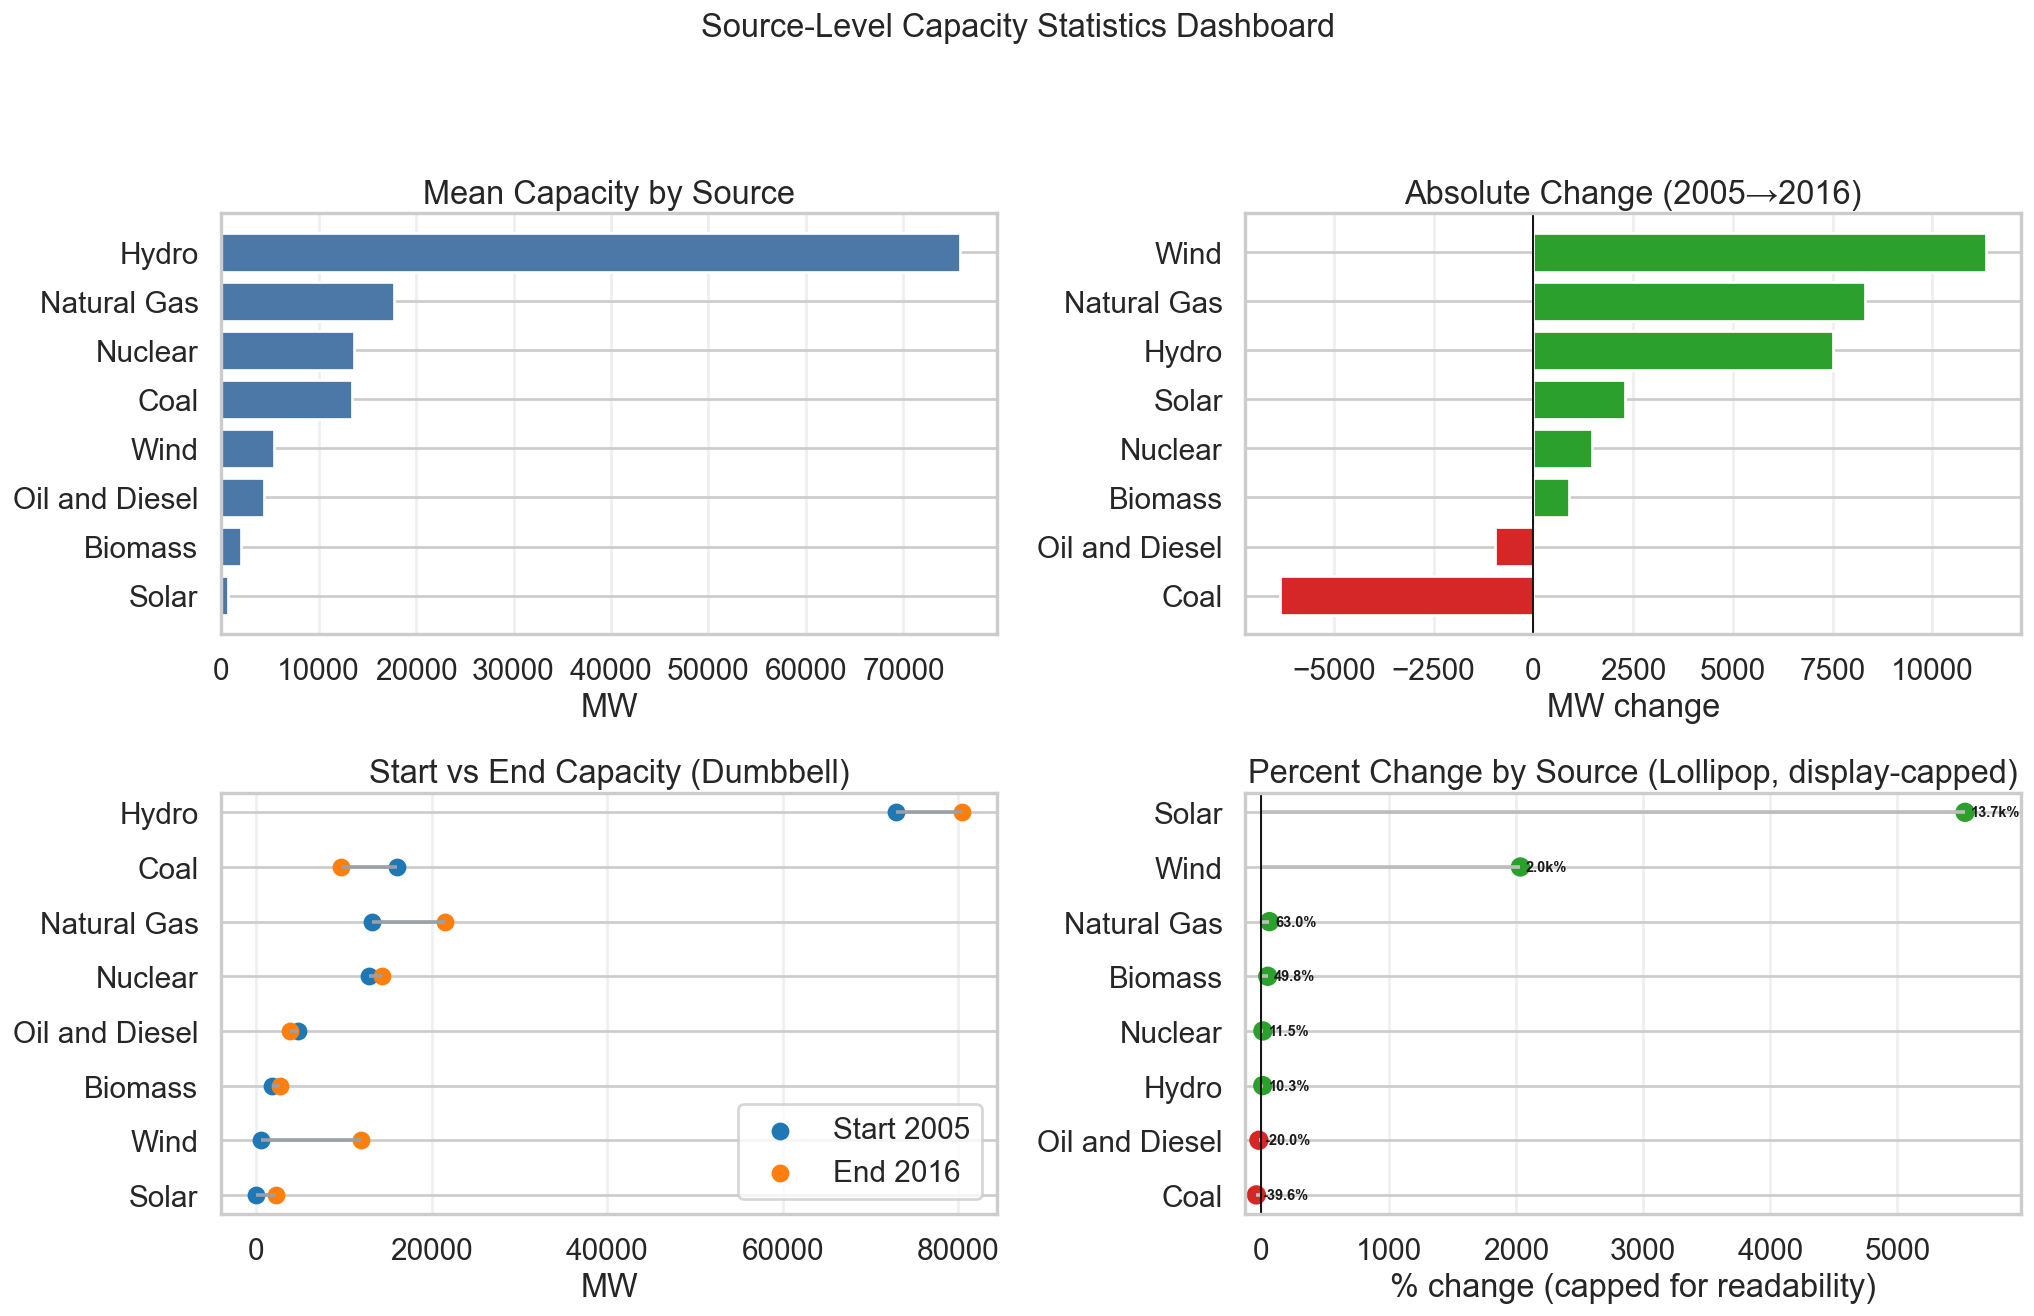

,Source,start,end,abs_change,pct_change,capacity_mean,cv_pct
0,Wind,557.3700,11902.400,11345.0300,2035.457595,5384.986667,72.297772
1,Natural Gas,13190.6100,21499.420,8308.8100,62.990339,17697.974583,18.314723
2,Hydro,72889.8310,80403.110,7513.2790,10.307719,75840.566667,3.290211
3,Solar,16.7500,2309.538,2292.7880,13688.286567,711.201917,119.060809
4,Nuclear,12805.0000,14273.000,1468.0000,11.464272,13615.333333,3.834467
5,Biomass,1804.0882,2702.290,898.2018,49.787023,2018.356683,15.673586
6,Oil and Diesel,4794.7600,3836.755,-958.0050,-19.980249,4405.227083,9.382646
7,Coal,16002.6400,9661.440,-6341.2000,-39.625962,13391.690000,19.509785


In [3]:
# EDA table + polished multi-panel source statistics visual
canada = df[df["Region"] == "Canada"].copy()
source_summary = canada.groupby("Source", as_index=False).agg(
    capacity_mean=("Data", "mean"),
    capacity_min=("Data", "min"),
    capacity_max=("Data", "max"),
    capacity_std=("Data", "std"),
)

start_year, end_year = int(df["Year"].min()), int(df["Year"].max())
start_vals = canada[canada["Year"] == start_year][["Source", "Data"]].rename(columns={"Data": "start"})
end_vals = canada[canada["Year"] == end_year][["Source", "Data"]].rename(columns={"Data": "end"})

source_summary = source_summary.merge(start_vals, on="Source", how="left").merge(end_vals, on="Source", how="left")
source_summary["abs_change"] = source_summary["end"] - source_summary["start"]
source_summary["pct_change"] = np.where(
    source_summary["start"] > 0,
    (source_summary["end"] / source_summary["start"] - 1) * 100,
    np.nan,
)
source_summary["range"] = source_summary["capacity_max"] - source_summary["capacity_min"]
source_summary["cv_pct"] = np.where(
    source_summary["capacity_mean"] > 0,
    (source_summary["capacity_std"] / source_summary["capacity_mean"]) * 100,
    np.nan,
)

source_summary = source_summary.sort_values("abs_change", ascending=False).reset_index(drop=True)

# Customized display table
table_cols = [
    "Source", "start", "end", "abs_change", "pct_change",
    "capacity_mean", "capacity_min", "capacity_max", "cv_pct",
]
styled = (
    source_summary[table_cols]
    .style
    .format({
        "start": "{:,.1f}",
        "end": "{:,.1f}",
        "abs_change": "{:+,.1f}",
        "pct_change": "{:+,.1f}%",
        "capacity_mean": "{:,.1f}",
        "capacity_min": "{:,.1f}",
        "capacity_max": "{:,.1f}",
        "cv_pct": "{:.1f}%",
    })
    .background_gradient(subset=["abs_change"], cmap="RdYlGn")
    .background_gradient(subset=["pct_change"], cmap="RdYlGn")
    .background_gradient(subset=["capacity_mean"], cmap="Blues")
    .set_caption(f"Source-Level Capacity Statistics ({start_year}–{end_year})")
    .hide(axis="index")
)
display(styled)

# Multi-panel visuals with varied chart types
panel_df = source_summary.copy()
panel_df["change_color"] = np.where(panel_df["abs_change"] >= 0, "#2ca02c", "#d62728")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Source-Level Capacity Statistics Dashboard", fontsize=18, y=1.02)

# Panel 1: Mean capacity by source (horizontal bar)
mean_df = panel_df.sort_values("capacity_mean", ascending=True)
axes[0, 0].barh(mean_df["Source"], mean_df["capacity_mean"], color="#4c78a8")
axes[0, 0].set_title("Mean Capacity by Source")
axes[0, 0].set_xlabel("MW")
axes[0, 0].grid(axis="x", alpha=0.3)

# Panel 2: Diverging change chart (positive vs negative)
change_df = panel_df.sort_values("abs_change", ascending=True)
axes[0, 1].barh(change_df["Source"], change_df["abs_change"], color=change_df["change_color"])
axes[0, 1].axvline(0, color="black", linewidth=1)
axes[0, 1].set_title(f"Absolute Change ({start_year}→{end_year})")
axes[0, 1].set_xlabel("MW change")
axes[0, 1].grid(axis="x", alpha=0.3)

# Panel 3: Start vs End dumbbell comparison
dumbbell_df = panel_df.sort_values("start", ascending=True).reset_index(drop=True)
y = np.arange(len(dumbbell_df))
axes[1, 0].hlines(y=y, xmin=dumbbell_df["start"], xmax=dumbbell_df["end"], color="#9aa0a6", linewidth=2)
axes[1, 0].scatter(dumbbell_df["start"], y, color="#1f77b4", s=70, label=f"Start {start_year}")
axes[1, 0].scatter(dumbbell_df["end"], y, color="#ff7f0e", s=70, label=f"End {end_year}")
axes[1, 0].set_yticks(y)
axes[1, 0].set_yticklabels(dumbbell_df["Source"])

axes[1, 0].set_title("Start vs End Capacity (Dumbbell)")
axes[1, 0].set_xlabel("MW")
axes[1, 0].legend(frameon=True)
axes[1, 0].grid(axis="x", alpha=0.3)

# Panel 4: Percent change lollipop (capped display; true values annotated)
lolli_df = panel_df.sort_values("pct_change", ascending=True).reset_index(drop=True)
pct_cap_high = lolli_df["pct_change"].quantile(0.90)
lolli_df["pct_plot"] = lolli_df["pct_change"].clip(upper=pct_cap_high)
y2 = np.arange(len(lolli_df))
axes[1, 1].hlines(y=y2, xmin=0, xmax=lolli_df["pct_plot"], color="#bdbdbd", linewidth=2)
axes[1, 1].scatter(
    lolli_df["pct_plot"],
    y2,
    c=np.where(lolli_df["pct_change"] >= 0, "#2ca02c", "#d62728"),
    s=85,
)

def fmt_pct_label(v: float) -> str:
    if not np.isfinite(v):
        return "NA"
    av = abs(v)
    if av >= 1000:
        return f"{v / 1000:.1f}k%"
    if av >= 100:
        return f"{v:,.0f}%"
    if av >= 10:
        return f"{v:.1f}%"
    return f"{v:.2f}%"

ann_offset = 0.008 * max(1.0, pct_cap_high)
for i, val in enumerate(lolli_df["pct_change"]):
    axes[1, 1].text(
        lolli_df.loc[i, "pct_plot"] + ann_offset,
        i,
        fmt_pct_label(float(val)),
        va="center",
        fontsize=8,
        color="#1a1a1a",
        fontweight="semibold",
        clip_on=False,
    )
x_min = min(float(lolli_df["pct_plot"].min()), 0.0) - ann_offset * 2
x_max = float(lolli_df["pct_plot"].max()) + ann_offset * 10
axes[1, 1].set_xlim(x_min, x_max)
axes[1, 1].axvline(0, color="black", linewidth=1)
axes[1, 1].set_yticks(y2)
axes[1, 1].set_yticklabels(lolli_df["Source"])
axes[1, 1].set_title("Percent Change by Source (Lollipop, display-capped)")
axes[1, 1].set_xlabel("% change (capped for readability)")
axes[1, 1].grid(axis="x", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

display(source_summary[["Source", "start", "end", "abs_change", "pct_change", "capacity_mean", "cv_pct"]])

### Interpretation of Source-Level Summary Statistics
Source-level start–end comparisons identify which technologies are driving expansion and which remain structurally stable. This establishes the scale context required before regional segmentation and predictive modelling.

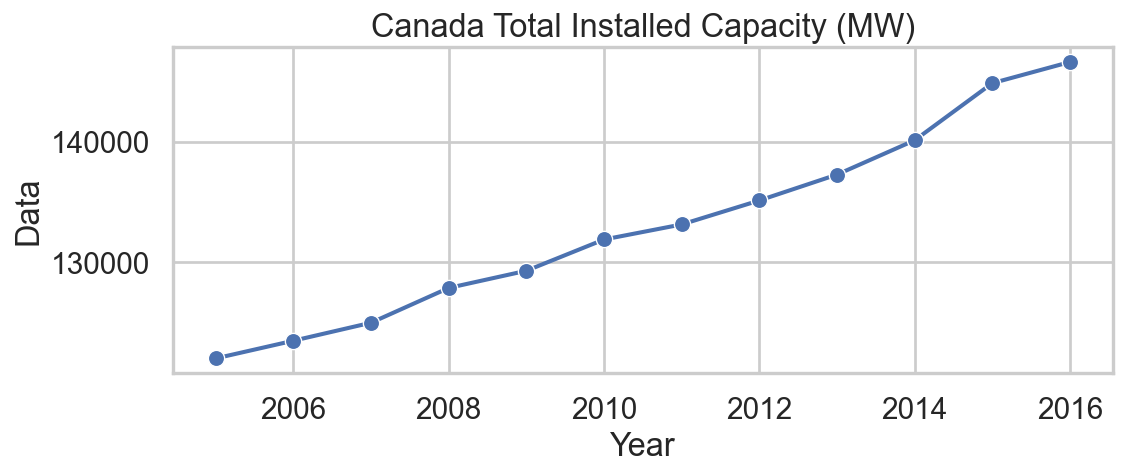

,Region,renew_share,non_renew_share
131,QC,0.974005,0.025995
23,BC,0.965418,0.034582
35,MB,0.917707,0.082293
59,NL,0.890953,0.109047
155,YT,0.767167,0.232833
119,PE,0.561408,0.438592
107,ON,0.416932,0.583068
83,NT,0.352088,0.647912
71,NS,0.345242,0.654758
47,NB,0.305817,0.694183


In [4]:
# EDA visuals (compact, non-duplicative)
renew_sources = {"Hydro", "Wind", "Solar", "Biomass"}

# 1) Canada total capacity trend
can_tot = canada.groupby("Year", as_index=False)["Data"].sum()
plt.figure(figsize=(9, 4))
sns.lineplot(data=can_tot, x="Year", y="Data", marker="o")
plt.title("Canada Total Installed Capacity (MW)")
plt.tight_layout()
plt.show()

# Core regional renewable-share panel used by downstream sections
region_year = df[df["Region"] != "Canada"].groupby(["Region", "Year"], as_index=False)["Data"].sum().rename(columns={"Data": "total"})
region_ren = (
    df[(df["Region"] != "Canada") & (df["Source"].isin(renew_sources))]
    .groupby(["Region", "Year"], as_index=False)["Data"].sum()
    .rename(columns={"Data": "renew"})
)
region_mix = region_year.merge(region_ren, on=["Region", "Year"], how="left").fillna({"renew": 0.0})
region_mix["renew_share"] = region_mix["renew"] / region_mix["total"]
region_mix["non_renew_share"] = 1.0 - region_mix["renew_share"]

latest = region_mix[region_mix["Year"] == region_mix["Year"].max()].sort_values("renew_share", ascending=False)
display(latest[["Region", "renew_share", "non_renew_share"]])

## 3A. Structural EDA for Methodological Direction

Structural exploratory analysis identifies heterogeneity, volatility, concentration, and growth asymmetry that determine model family choice and validation design.

In [5]:
# Structural EDA (compact)
start_year = int(df["Year"].min())
end_year = int(df["Year"].max())

# Region-source growth evidence table
rs_start = df[df["Year"] == start_year][["Region", "Source", "Data"]].rename(columns={"Data": "start"})
rs_end = df[df["Year"] == end_year][["Region", "Source", "Data"]].rename(columns={"Data": "end"})
rs_growth = rs_start.merge(rs_end, on=["Region", "Source"], how="inner")
rs_growth["pct_change"] = np.where(
    rs_growth["start"] > 0,
    (rs_growth["end"] - rs_growth["start"]) / rs_growth["start"] * 100.0,
    np.nan,
)

# Volatility evidence table
rs_vol = (
    df[df["Region"] != "Canada"]
    .groupby(["Region", "Source"], as_index=False)["Data"]
    .std()
    .rename(columns={"Data": "std_capacity"})
)

# Structural summary constructed directly from observed data
reg_year_total = (
    df[df["Region"] != "Canada"]
    .groupby(["Region", "Year"], as_index=False)["Data"]
    .sum()
    .rename(columns={"Data": "region_total"})
)
reg_year_renew = (
    df[(df["Region"] != "Canada") & (df["Source"].isin(renew_sources))]
    .groupby(["Region", "Year"], as_index=False)["Data"]
    .sum()
    .rename(columns={"Data": "renew_total"})
)
reg_mix = reg_year_total.merge(reg_year_renew, on=["Region", "Year"], how="left").fillna({"renew_total": 0.0})
reg_mix["renew_share"] = reg_mix["renew_total"] / reg_mix["region_total"]
reg_mix["fossil_share"] = 1.0 - reg_mix["renew_share"]

shares_tmp = df[df["Region"] != "Canada"][["Region", "Year", "Source", "Data"]].merge(
    reg_year_total, on=["Region", "Year"], how="left"
 )
shares_tmp["src_share"] = shares_tmp["Data"] / shares_tmp["region_total"]
hhi_tmp = (
    shares_tmp.groupby(["Region", "Year"], as_index=False)
    .apply(lambda x: (x["src_share"] ** 2).sum(), include_groups=False)
    .rename(columns={None: "hhi"})
)
reg_mix = reg_mix.merge(hhi_tmp, on=["Region", "Year"], how="left")

r_start = reg_mix[reg_mix["Year"] == start_year][["Region", "renew_share"]].rename(columns={"renew_share": "renew_start"})
r_end = reg_mix[reg_mix["Year"] == end_year][["Region", "renew_share"]].rename(columns={"renew_share": "renew_end"})
reg_delta = r_start.merge(r_end, on="Region", how="inner")
reg_delta["renew_delta"] = reg_delta["renew_end"] - reg_delta["renew_start"]

region_struct = (
    reg_mix.groupby("Region", as_index=False)
    .agg(
        renew_mean=("renew_share", "mean"),
        fossil_mean=("fossil_share", "mean"),
        hhi_mean=("hhi", "mean"),
        capacity_mean=("region_total", "mean"),
    )
    .merge(reg_delta[["Region", "renew_delta"]], on="Region", how="left")
)

q_end = region_struct["renew_mean"].median()
q_delta = region_struct["renew_delta"].median()
region_struct["TransitionRegime"] = np.select(
    [
        (region_struct["renew_mean"] >= q_end) & (region_struct["renew_delta"] >= q_delta),
        (region_struct["renew_mean"] < q_end) & (region_struct["renew_delta"] >= q_delta),
        (region_struct["renew_mean"] >= q_end) & (region_struct["renew_delta"] < q_delta),
    ],
    ["Leader", "Emerging", "Mature-Stable"],
    default="Lagging",
)

fig_struct = px.scatter(
    region_struct,
    x="renew_mean",
    y="hhi_mean",
    size="capacity_mean",
    color="TransitionRegime",
    hover_name="Region",
    title="Structural Regime Map: Renewable Share vs Concentration (size = system scale)",
    labels={"renew_mean": "Average Renewable Share", "hhi_mean": "Average Concentration (HHI)"},
)
display(fig_struct)

top_growth = rs_growth.sort_values("pct_change", ascending=False).head(15)
top_volatility = rs_vol.groupby("Source", as_index=False)["std_capacity"].mean().sort_values("std_capacity", ascending=False)
display(top_growth)
display(top_volatility)

evidence_to_method = pd.DataFrame(
    [
        ["Large cross-region spread in renewable and concentration structure", "One global profile is insufficient", "Perform clustering before supervised modelling"],
        ["Non-linear regime separation in structure space", "Linear boundaries may underfit", "Prioritize non-linear classifiers in benchmark"],
        ["Source-level volatility asymmetry", "Error risk differs by source", "Use temporal validation and source-wise diagnostics"],
    ],
    columns=["Structural EDA Evidence", "Modelling Implication", "Implemented Choice"],
)
display(evidence_to_method)

,Region,Source,start,end,pct_change
79,ON,Wind,15.00,4841.450,32176.333333
22,Canada,Solar,16.75,2309.538,13688.286567
78,ON,Solar,16.75,2291.460,13580.358209
23,Canada,Wind,557.37,11902.400,2035.457595
91,QC,Natural Gas,31.05,591.130,1803.800322
95,QC,Wind,207.00,3549.320,1614.647343
87,PE,Wind,13.00,203.280,1463.692308
55,NS,Wind,34.70,515.400,1385.302594
101,SK,Oil and Diesel,1.17,16.955,1349.145299
103,SK,Wind,15.86,221.180,1294.577554


,Source,std_capacity
7,Wind,308.179358
3,Natural Gas,297.102788
1,Coal,233.435966
2,Hydro,202.718846
4,Nuclear,90.612207
6,Solar,65.176226
5,Oil and Diesel,44.503553
0,Biomass,27.564226


,Structural EDA Evidence,Modelling Implication,Implemented Choice
0,Large cross-region spread in renewable and con...,One global profile is insufficient,Perform clustering before supervised modelling
1,Non-linear regime separation in structure space,Linear boundaries may underfit,Prioritize non-linear classifiers in benchmark
2,Source-level volatility asymmetry,Error risk differs by source,Use temporal validation and source-wise diagno...


### Methodological Implications from Structural EDA
Structural evidence indicates cross-region heterogeneity, non-linear regime separation, and source-level volatility asymmetry. The selected workflow—clustering, non-linear benchmarking, and temporal/source-wise diagnostics—is therefore empirically justified rather than arbitrary.

## 3B. Method Selection and Sequencing Rationale
Model selection is anchored in observed data structure, interpretability needs, and validation robustness.

**Clustering methods implemented in this notebook:**
- KMeans
- Agglomerative clustering
- Gaussian Mixture
- DBSCAN

**Classification families implemented in this notebook:**
- Linear models (Logistic Regression, LDA)
- Probabilistic model (Gaussian Naive Bayes, QDA)
- Distance/kernel models (KNN, SVC)
- Tree ensembles (Random Forest, ExtraTrees, HistGradientBoosting)

The workflow applies clustering first and classification second. Unsupervised segmentation identifies latent regional regimes without label assumptions, after which supervised models map engineered features to transition classes. This sequencing improves interpretability by comparing class behavior within structurally similar regional groups rather than one pooled population.

In [6]:
# Evidence-to-method traceability matrix
method_trace = pd.DataFrame(
    [
        ["High regional heterogeneity", "Unsupervised segmentation", "Best-performing clustering configuration selected from method scan"],
        ["Potentially non-linear class boundaries", "Non-linear supervised benchmark", "RandomForest and HistGradientBoostingClassifier included"],
        ["Need for parsimonious reference model", "Probabilistic baseline", "GaussianNB included"],
        ["Need for interpretable linear comparator", "Linear discriminative baseline", "LogisticRegression included"],
        ["Temporal dependence in trajectories", "Leakage-safe forecasting", "Lagged-only features with time-ordered evaluation"],
    ],
    columns=["Observed Structure", "Methodological Requirement", "Operational Decision"],
)
display(method_trace)

,Observed Structure,Methodological Requirement,Operational Decision
0,High regional heterogeneity,Unsupervised segmentation,Best-performing clustering configuration selec...
1,Potentially non-linear class boundaries,Non-linear supervised benchmark,RandomForest and HistGradientBoostingClassifie...
2,Need for parsimonious reference model,Probabilistic baseline,GaussianNB included
3,Need for interpretable linear comparator,Linear discriminative baseline,LogisticRegression included
4,Temporal dependence in trajectories,Leakage-safe forecasting,Lagged-only features with time-ordered evaluation


### Interpretation of Exploratory Patterns
National capacity rises over time, while latest-year renewable shares differ materially across regions. National averages alone can therefore mask policy-relevant regional disparities, which justifies region-level modelling.

## 4. Feature Engineering

In [7]:
def build_panel_features(data: pd.DataFrame) -> pd.DataFrame:
    panel = data.copy().sort_values(["Region", "Source", "Year"])

    group_rs = panel.groupby(["Region", "Source"])
    panel["lag1"] = group_rs["Data"].shift(1)
    panel["lag2"] = group_rs["Data"].shift(2)
    panel["growth_yoy"] = group_rs["Data"].pct_change().shift(1)
    panel["roll_mean_3"] = group_rs["Data"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    panel["roll_std_3"] = group_rs["Data"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).std()).fillna(0.0)

    region_year_total = panel.groupby(["Region", "Year"], as_index=False)["Data"].sum().rename(columns={"Data": "region_total"})
    ren = (
        panel[panel["Source"].isin(renew_sources)]
        .groupby(["Region", "Year"], as_index=False)["Data"]
        .sum()
        .rename(columns={"Data": "renew_total"})
    )
    mix = region_year_total.merge(ren, on=["Region", "Year"], how="left").fillna({"renew_total": 0.0})
    mix["renew_share"] = mix["renew_total"] / mix["region_total"]
    mix["fossil_share"] = 1.0 - mix["renew_share"]

    panel = panel.merge(mix[["Region", "Year", "region_total", "renew_share", "fossil_share"]], on=["Region", "Year"], how="left")

    shares = panel[["Region", "Year", "Source", "Data"]].merge(region_year_total, on=["Region", "Year"], how="left")
    shares["src_share"] = shares["Data"] / shares["region_total"]
    hhi = shares.groupby(["Region", "Year"], as_index=False).apply(lambda x: (x["src_share"] ** 2).sum(), include_groups=False)
    hhi = hhi.rename(columns={None: "hhi"})

    panel = panel.merge(hhi, on=["Region", "Year"], how="left")
    panel.replace([np.inf, -np.inf], np.nan, inplace=True)
    return panel

panel = build_panel_features(df)
print("Panel rows:", len(panel))
display(panel.head())

Panel rows: 1344


,Region,Source,Year,Data,Unit,lag1,lag2,growth_yoy,roll_mean_3,roll_std_3,region_total,renew_share,fossil_share,hhi
0,AB,Biomass,2005,271.0,MW,NaN,NaN,NaN,NaN,0.000000,12008.15,0.115838,0.884162,0.400499
1,AB,Biomass,2006,313.1,MW,271.0,NaN,NaN,271.000000,0.000000,11769.25,0.133662,0.866338,0.390593
2,AB,Biomass,2007,313.1,MW,313.1,271.0,0.155351,292.050000,29.769195,12062.25,0.141939,0.858061,0.383105
3,AB,Biomass,2008,313.1,MW,313.1,313.1,0.000000,299.066667,24.306446,12460.25,0.137405,0.862595,0.382729
4,AB,Biomass,2009,323.2,MW,313.1,313.1,0.000000,313.100000,0.000000,12905.35,0.138563,0.861437,0.379949


In [8]:
feature_dictionary = pd.DataFrame(
    [
        ["lag1", "MW", "Capacity at t-1 for same Region-Source", "Forecasting", "Yes"],
        ["lag2", "MW", "Capacity at t-2 for same Region-Source", "Forecasting", "Yes"],
        ["growth_yoy", "ratio", "Lagged year-over-year growth", "Forecasting", "Yes"],
        ["roll_mean_3", "MW", "Lagged 3-year rolling mean", "Forecasting", "Yes"],
        ["roll_std_3", "MW", "Lagged 3-year rolling std", "Forecasting", "Yes"],
        ["renew_share", "0-1", "Renewable share of total regional capacity", "Classification + Forecasting", "Yes"],
        ["fossil_share", "0-1", "1 - renew_share (compositional complement)", "Diagnostics only", "Yes"],
        ["hhi", "index", "Source concentration index per region-year", "Classification + Forecasting", "Yes"],
        ["region_total", "MW", "Total regional installed capacity", "Classification", "No (contemporaneous summary)"],
        ["renew_momentum", "delta", "Change in renewable share vs prior year", "Classification", "Yes"],
    ],
    columns=["Feature", "Unit", "Definition", "Used In", "Available At Prediction Time"],
)

display(feature_dictionary)

,Feature,Unit,Definition,Used In,Available At Prediction Time
0,lag1,MW,Capacity at t-1 for same Region-Source,Forecasting,Yes
1,lag2,MW,Capacity at t-2 for same Region-Source,Forecasting,Yes
2,growth_yoy,ratio,Lagged year-over-year growth,Forecasting,Yes
3,roll_mean_3,MW,Lagged 3-year rolling mean,Forecasting,Yes
4,roll_std_3,MW,Lagged 3-year rolling std,Forecasting,Yes
5,renew_share,0-1,Renewable share of total regional capacity,Classification + Forecasting,Yes
6,fossil_share,0-1,1 - renew_share (compositional complement),Diagnostics only,Yes
7,hhi,index,Source concentration index per region-year,Classification + Forecasting,Yes
8,region_total,MW,Total regional installed capacity,Classification,No (contemporaneous summary)
9,renew_momentum,delta,Change in renewable share vs prior year,Classification,Yes


### Interpretation of Engineered Feature Space
The predictive design uses lagged-only trajectory features to enforce temporal causality and reduce leakage risk. As a result, out-of-time performance estimates are more defensible for planning and policy use.

## 5. Unsupervised Learning: Regional Clustering

,Method,Config,status,reason,n_clusters,noise_points,silhouette,calinski_harabasz,davies_bouldin
0,DBSCAN,eps=0.6,ok,,2,9,0.895605,145.927581,0.104668
1,DBSCAN,eps=0.8,ok,,2,6,0.804137,78.124863,0.240478
2,DBSCAN,eps=1.0,ok,,2,5,0.777431,62.453311,0.269946
3,DBSCAN,eps=1.2,ok,,2,5,0.777431,62.453311,0.269946
4,KMeans,k=4,ok,,4,0,0.459785,10.715451,0.434914
5,Agglomerative,k=4,ok,,4,0,0.459785,10.715451,0.434914
6,GaussianMixture,k=4,ok,,4,0,0.459785,10.715451,0.434914
7,KMeans,k=3,ok,,3,0,0.455806,9.130050,0.585200
8,Agglomerative,k=3,ok,,3,0,0.455806,9.130050,0.585200
9,KMeans,k=5,ok,,5,0,0.439182,13.527245,0.352191


Selected clustering: DBSCAN | eps=0.6 | silhouette: 0.8956


,Region,Cluster,ClusterLabel
0,MB,0,Cluster 0
1,NL,0,Cluster 0
2,NB,1,Cluster 1
3,SK,1,Cluster 1
4,AB,2,Cluster 2
5,BC,2,Cluster 2
6,NS,2,Cluster 2
7,NT,2,Cluster 2
8,NU,2,Cluster 2
9,ON,2,Cluster 2


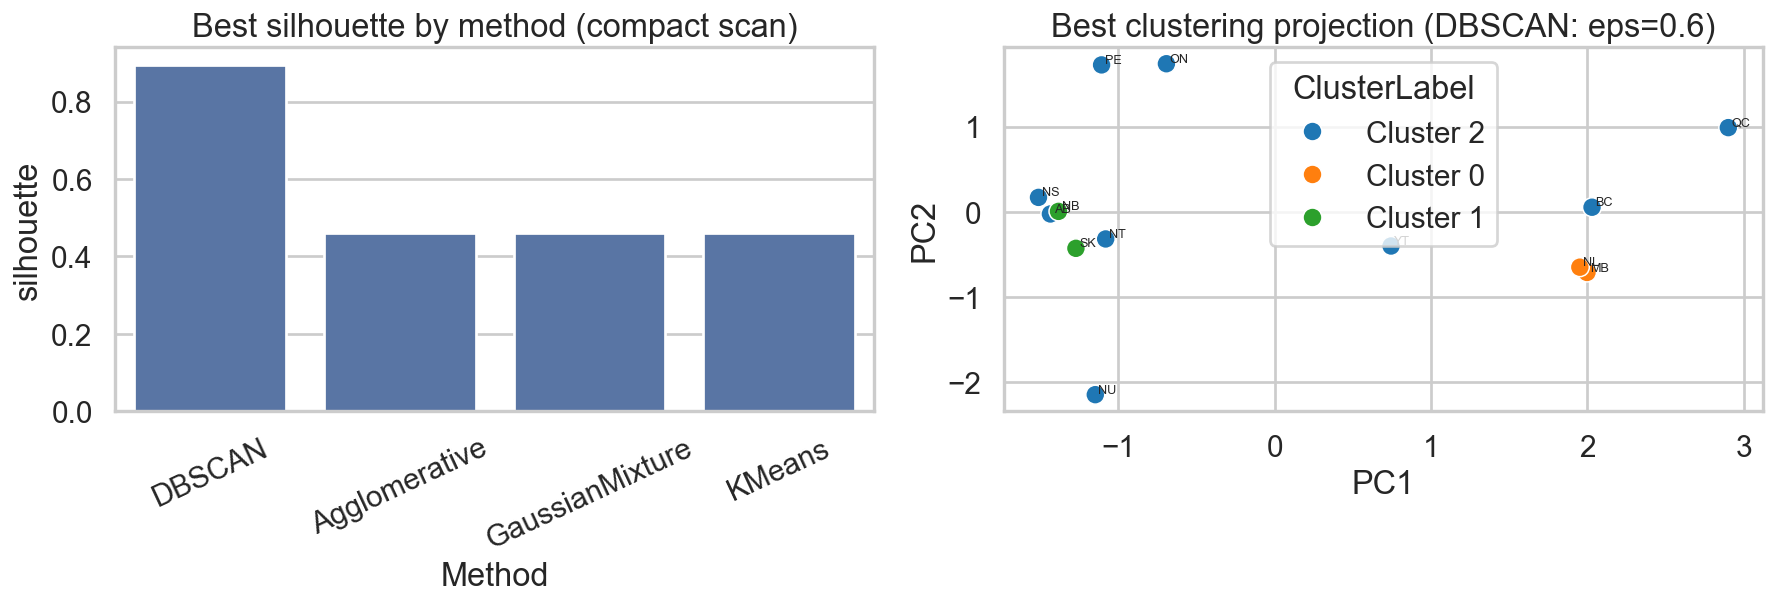

In [9]:
panel_region = panel[panel["Region"] != "Canada"].copy()

region_features = (
    panel_region.groupby(["Region", "Year"], as_index=False)
    .agg(
        renew_share=("renew_share", "mean"),
        fossil_share=("fossil_share", "mean"),
        hhi=("hhi", "mean"),
        total_capacity=("region_total", "mean"),
    )
    .groupby("Region", as_index=False)
    .agg(
        renew_share_mean=("renew_share", "mean"),
        renew_share_std=("renew_share", "std"),
        fossil_share_mean=("fossil_share", "mean"),
        hhi_mean=("hhi", "mean"),
        capacity_mean=("total_capacity", "mean"),
    )
    .fillna(0.0)
)

cluster_input = region_features.drop(columns=["Region"]).copy()
cluster_scaled = StandardScaler().fit_transform(cluster_input)
n_regions = cluster_scaled.shape[0]
k_grid = [k for k in [2, 3, 4, 5] if k < n_regions]

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture

scan_rows = []
label_store = {}

def eval_and_store(method: str, config: str, labels: np.ndarray, k_value: float | None = None):
    labels = np.asarray(labels)
    has_noise = (labels == -1).any()
    usable_mask = labels != -1 if has_noise else np.ones(len(labels), dtype=bool)
    usable_labels = labels[usable_mask]
    n_clusters = len(np.unique(usable_labels))

    if n_clusters < 2 or usable_mask.sum() <= n_clusters:
        scan_rows.append({
            "Method": method,
            "Config": config,
            "k": np.nan if k_value is None else k_value,
            "status": "invalid",
            "reason": "insufficient usable clusters",
            "n_clusters": int(n_clusters),
            "noise_points": int((labels == -1).sum()) if has_noise else 0,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        })
        return

    X_eval = cluster_scaled[usable_mask]
    y_eval = usable_labels
    scan_rows.append({
        "Method": method,
        "Config": config,
        "k": np.nan if k_value is None else k_value,
        "status": "ok",
        "reason": "",
        "n_clusters": int(n_clusters),
        "noise_points": int((labels == -1).sum()) if has_noise else 0,
        "silhouette": float(silhouette_score(X_eval, y_eval)),
        "calinski_harabasz": float(calinski_harabasz_score(X_eval, y_eval)),
        "davies_bouldin": float(davies_bouldin_score(X_eval, y_eval)),
    })
    label_store[(method, config)] = labels.copy()

# Compact benchmark: KMeans, Agglomerative, GaussianMixture, DBSCAN
for k in k_grid:
    eval_and_store(
        "KMeans",
        f"k={k}",
        KMeans(n_clusters=k, n_init=30, random_state=42).fit_predict(cluster_scaled),
        k_value=k,
    )
    eval_and_store(
        "Agglomerative",
        f"k={k}",
        AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(cluster_scaled),
        k_value=k,
    )
    eval_and_store(
        "GaussianMixture",
        f"k={k}",
        GaussianMixture(n_components=k, covariance_type="full", random_state=42).fit_predict(cluster_scaled),
        k_value=k,
    )

for eps in [0.6, 0.8, 1.0, 1.2]:
    eval_and_store(
        "DBSCAN",
        f"eps={eps}",
        DBSCAN(eps=eps, min_samples=2).fit_predict(cluster_scaled),
    )

cluster_method_df = pd.DataFrame(scan_rows).sort_values(
    ["status", "silhouette", "calinski_harabasz"],
    ascending=[True, False, False],
    na_position="last",
).reset_index(drop=True)
display(cluster_method_df[["Method", "Config", "status", "reason", "n_clusters", "noise_points", "silhouette", "calinski_harabasz", "davies_bouldin"]])

valid_df = cluster_method_df[cluster_method_df["status"] == "ok"].copy()
if valid_df.empty:
    raise RuntimeError("No clustering method produced valid output.")

best_row = valid_df.sort_values(["silhouette", "calinski_harabasz"], ascending=[False, False]).iloc[0]
best_method = str(best_row["Method"])
best_config = str(best_row["Config"])
best_labels = label_store[(best_method, best_config)].copy()

if (best_labels == -1).any():
    replacement = int(best_labels[best_labels != -1].max() + 1) if (best_labels != -1).any() else 0
    best_labels = np.where(best_labels == -1, replacement, best_labels)

region_features["Cluster"] = best_labels.astype(int)
region_features["ClusterLabel"] = "Cluster " + region_features["Cluster"].astype(str)
best_k = int(region_features["Cluster"].nunique())
print("Selected clustering:", best_method, "|", best_config, "| silhouette:", round(float(best_row["silhouette"]), 4))

cluster_audit = region_features[["Region", "Cluster", "ClusterLabel"]].sort_values(["Cluster", "Region"]).reset_index(drop=True)
display(cluster_audit)

# Compact diagnostic figure
pca_xy = PCA(n_components=2, random_state=42).fit_transform(cluster_scaled)
plot_df = region_features[["Region", "ClusterLabel"]].copy()
plot_df["PC1"] = pca_xy[:, 0]
plot_df["PC2"] = pca_xy[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
best_per_method = valid_df.sort_values(["Method", "silhouette"], ascending=[True, False]).groupby("Method", as_index=False).first()
sns.barplot(data=best_per_method.sort_values("silhouette", ascending=False), x="Method", y="silhouette", ax=axes[0])
axes[0].set_title("Best silhouette by method (compact scan)")
axes[0].tick_params(axis="x", rotation=25)

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="ClusterLabel", s=110, palette="tab10", ax=axes[1])
for _, row in plot_df.iterrows():
    axes[1].text(row["PC1"] + 0.02, row["PC2"] + 0.02, row["Region"], fontsize=7)
axes[1].set_title(f"Best clustering projection ({best_method}: {best_config})")

plt.tight_layout()
plt.show()

### Interpretation of Regional Clustering
The compact clustering benchmark preserves method diversity while adding explicit validity checks and transparent ranking. This improves auditability and reproducibility without increasing workflow complexity.

## 6. Supervised Learning: Transition Status Classification

Correlation(renew_share, fossil_share) = -1.000000
Modeling decision: fossil_share is excluded from predictors to avoid compositional redundancy.
GroupCV Accuracy mean±std: 0.2889 ± 0.2519
GroupCV F1-macro mean±std: 0.1944 ± 0.2008
Canada included in classification universe: False


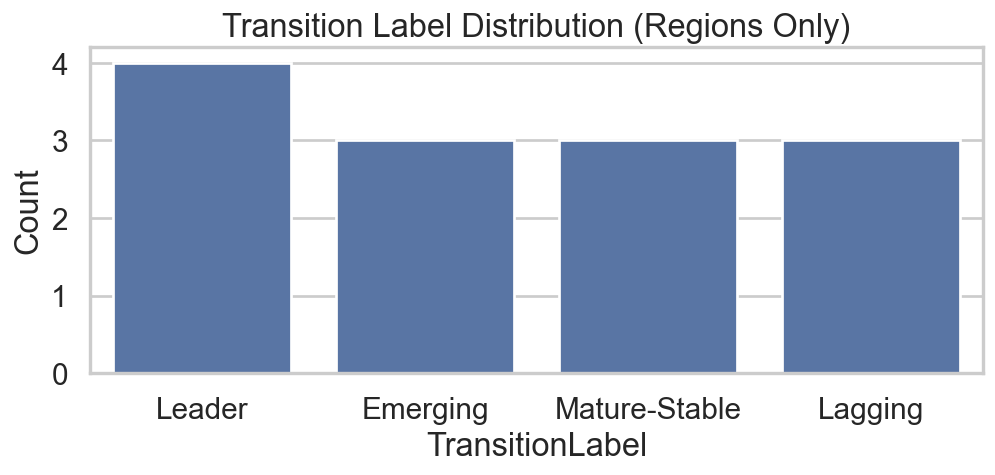

,Region,renew_end,renew_delta,TransitionLabel
0,AB,0.168220,0.052382,Emerging
1,BC,0.965418,0.058540,Leader
2,MB,0.917707,0.006740,Mature-Stable
3,NB,0.305817,0.050654,Lagging
4,NL,0.890953,0.006223,Mature-Stable
5,NS,0.345242,0.134658,Emerging
6,NT,0.352088,0.080765,Emerging
7,NU,0.002444,0.002444,Lagging
8,ON,0.416932,0.139621,Leader
9,PE,0.561408,0.475417,Leader


,feature,importance
2,hhi,0.367343
0,renew_share,0.351983
3,total_capacity,0.254391
1,renew_momentum,0.026283


In [10]:
# Label construction based on end-state renewable level and improvement (regions only)
years_sorted = sorted(df["Year"].unique())
y0, y1 = years_sorted[0], years_sorted[-1]

region_label_base = []
for reg in sorted(df[df["Region"] != "Canada"]["Region"].unique()):
    d0 = df[(df["Region"] == reg) & (df["Year"] == y0)]
    d1 = df[(df["Region"] == reg) & (df["Year"] == y1)]

    t0 = d0["Data"].sum()
    t1 = d1["Data"].sum()
    r0 = d0[d0["Source"].isin(renew_sources)]["Data"].sum() / t0 if t0 else 0.0
    r1 = d1[d1["Source"].isin(renew_sources)]["Data"].sum() / t1 if t1 else 0.0

    region_label_base.append({"Region": reg, "renew_end": r1, "renew_delta": r1 - r0})

label_df = pd.DataFrame(region_label_base)
cut_end = label_df["renew_end"].median()
cut_delta = label_df["renew_delta"].median()

def assign_label(r_end: float, r_delta: float) -> str:
    if r_end >= cut_end and r_delta >= cut_delta:
        return "Leader"
    if r_end < cut_end and r_delta >= cut_delta:
        return "Emerging"
    if r_end >= cut_end and r_delta < cut_delta:
        return "Mature-Stable"
    return "Lagging"

label_df["TransitionLabel"] = [assign_label(a, b) for a, b in zip(label_df["renew_end"], label_df["renew_delta"])]

def build_priority_table(label_data: pd.DataFrame, feature_data: pd.DataFrame) -> tuple[pd.DataFrame, float, float]:
    tbl = label_data.merge(
        feature_data[["Region", "fossil_share_mean", "capacity_mean", "Cluster"]],
        on="Region",
        how="left",
    ).copy()
    tbl["TransitionScore"] = (
        0.55 * tbl["renew_end"].rank(pct=True)
        + 0.45 * tbl["renew_delta"].rank(pct=True)
    ) * 100.0
    priority_raw = (
        0.60 * (1.0 - tbl["TransitionScore"] / 100.0)
        + 0.25 * tbl["fossil_share_mean"].rank(pct=True)
        + 0.15 * tbl["capacity_mean"].rank(pct=True)
    )
    tbl["PriorityScore"] = (priority_raw * 100.0).round(1)
    q_high = float(tbl["PriorityScore"].quantile(2 / 3))
    q_mid = float(tbl["PriorityScore"].quantile(1 / 3))
    tbl["Priority"] = np.select(
        [tbl["PriorityScore"] >= q_high, tbl["PriorityScore"] >= q_mid],
        ["High", "Medium"],
        default="Low",
    )
    tbl = tbl.sort_values(["PriorityScore", "capacity_mean"], ascending=[False, False])
    return tbl, q_high, q_mid

clf_data = panel.groupby(["Region", "Year"], as_index=False).agg(
    renew_share=("renew_share", "mean"),
    fossil_share=("fossil_share", "mean"),
    hhi=("hhi", "mean"),
    total_capacity=("region_total", "mean"),
)
clf_data = clf_data[clf_data["Region"] != "Canada"].sort_values(["Region", "Year"]).reset_index(drop=True)
clf_data["renew_share_lag1"] = clf_data.groupby("Region")["renew_share"].shift(1)
clf_data["renew_momentum"] = (clf_data["renew_share"] - clf_data["renew_share_lag1"]).fillna(0.0)
clf_data = clf_data.merge(label_df[["Region", "TransitionLabel"]], on="Region", how="left")

renew_fossil_corr = clf_data[["renew_share", "fossil_share"]].corr().iloc[0, 1]
print(f"Correlation(renew_share, fossil_share) = {renew_fossil_corr:.6f}")
print("Modeling decision: fossil_share is excluded from predictors to avoid compositional redundancy.")

feature_cols_clf = ["renew_share", "renew_momentum", "hhi", "total_capacity"]
X = clf_data[feature_cols_clf]
y = clf_data["TransitionLabel"]
groups = clf_data["Region"]

rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
gkf = GroupKFold(n_splits=5)

acc_cv = cross_val_score(rf, X, y, cv=gkf, groups=groups, scoring="accuracy")
f1_cv = cross_val_score(rf, X, y, cv=gkf, groups=groups, scoring="f1_macro")

print("GroupCV Accuracy mean±std:", round(acc_cv.mean(), 4), "±", round(acc_cv.std(), 4))
print("GroupCV F1-macro mean±std:", round(f1_cv.mean(), 4), "±", round(f1_cv.std(), 4))
print("Canada included in classification universe:", bool((label_df["Region"] == "Canada").any()))

rf.fit(X, y)
imp = pd.DataFrame({"feature": X.columns, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)

transition_counts = label_df["TransitionLabel"].value_counts().rename_axis("TransitionLabel").reset_index(name="Count")
plt.figure(figsize=(8, 4))
sns.barplot(data=transition_counts, x="TransitionLabel", y="Count")
plt.title("Transition Label Distribution (Regions Only)")
plt.tight_layout()
plt.show()

display(label_df)
display(imp)

### Interpretation of Classification Results
Fossil share is excluded because it is a near-compositional complement to renewable share and would otherwise introduce redundancy. The final predictor set therefore improves model stability and interpretability.

## 6B. Classification Benchmark Across Model Families

This section runs a compact benchmark across applicable linear, probabilistic, distance-based, kernel, and ensemble classifiers under the same GroupKFold protocol. Any model that fails to fit robustly is retained with an explicit status/reason.

,Model,Status,Reason,Accuracy_mean,Accuracy_std,F1_macro_mean,F1_macro_std
0,HistGradientBoosting,ok,,0.433333,0.292710,0.286717,0.197024
1,KNN,ok,,0.402778,0.242161,0.271381,0.180107
2,QDA,ok,,0.366667,0.305505,0.250952,0.211579
3,LDA,ok,,0.336111,0.211986,0.245464,0.167712
4,ExtraTrees,ok,,0.341667,0.261406,0.241717,0.192551
5,LogisticRegression,ok,,0.341667,0.263757,0.238352,0.197238
6,SVC-RBF,ok,,0.333333,0.289609,0.226846,0.201187
7,SVC-Linear,ok,,0.319444,0.289209,0.213376,0.195903
8,RandomForest,ok,,0.288889,0.251906,0.194378,0.200780
9,GaussianNB,ok,,0.066667,0.133333,0.033333,0.066667


,Emerging,Lagging,Leader,Mature-Stable
Emerging,8,12,16,0
Lagging,12,12,12,0
Leader,14,2,20,12
Mature-Stable,0,2,12,22


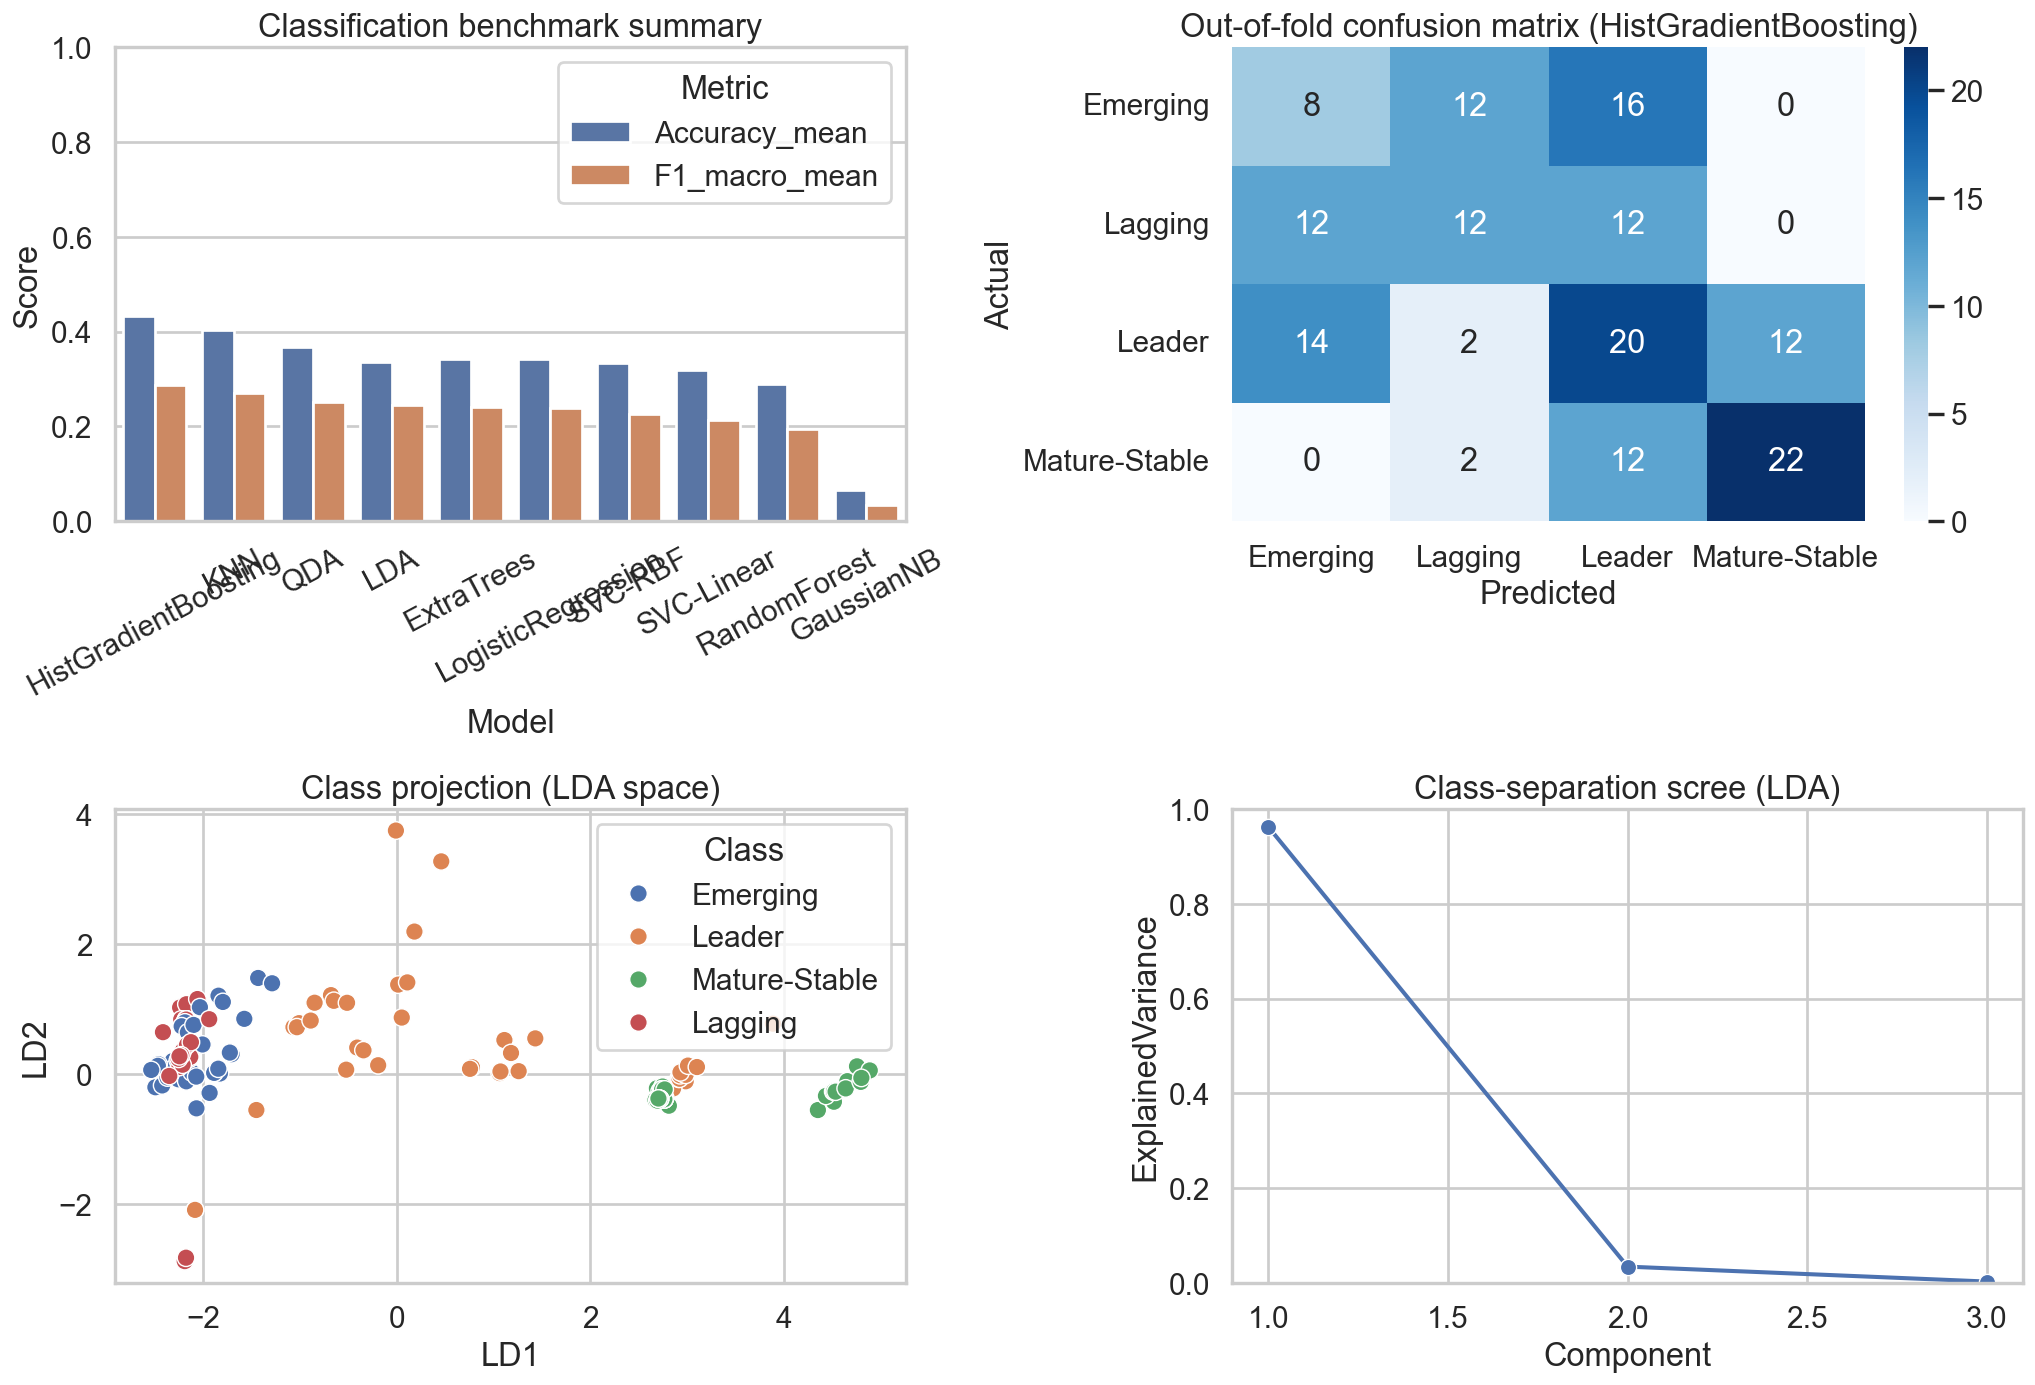

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

benchmark_models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced")),
    "GaussianNB": GaussianNB(),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "SVC-Linear": make_pipeline(StandardScaler(), SVC(kernel="linear", class_weight="balanced", random_state=42)),
    "SVC-RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced", gamma="scale", random_state=42)),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.05),
    "RandomForest": RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced"),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=500, random_state=42, class_weight="balanced"),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
}

def evaluate_classifier(name: str, mdl) -> tuple[dict, bool]:
    try:
        acc_scores = cross_val_score(mdl, X, y, cv=gkf, groups=groups, scoring="accuracy", error_score=np.nan)
        f1_scores = cross_val_score(mdl, X, y, cv=gkf, groups=groups, scoring="f1_macro", error_score=np.nan)
        if np.isnan(acc_scores).all() or np.isnan(f1_scores).all():
            raise ValueError("all folds returned NaN")
        return ({
            "Model": name,
            "Status": "ok",
            "Reason": "",
            "Accuracy_mean": float(np.nanmean(acc_scores)),
            "Accuracy_std": float(np.nanstd(acc_scores)),
            "F1_macro_mean": float(np.nanmean(f1_scores)),
            "F1_macro_std": float(np.nanstd(f1_scores)),
        }, True)
    except Exception as e:
        return ({
            "Model": name,
            "Status": "skipped",
            "Reason": str(e)[:140],
            "Accuracy_mean": np.nan,
            "Accuracy_std": np.nan,
            "F1_macro_mean": np.nan,
            "F1_macro_std": np.nan,
        }, False)

bench_rows = []
model_cache = {}
for name, mdl in benchmark_models.items():
    row, is_ok = evaluate_classifier(name, mdl)
    bench_rows.append(row)
    if is_ok:
        model_cache[name] = mdl

benchmark_df = pd.DataFrame(bench_rows).sort_values(
    ["Status", "F1_macro_mean", "Accuracy_mean"],
    ascending=[True, False, False],
    na_position="last",
).reset_index(drop=True)
display(benchmark_df)

valid_models = benchmark_df[benchmark_df["Status"] == "ok"].copy()
if valid_models.empty:
    raise RuntimeError("No classification model produced valid GroupKFold output.")

best_model_name = str(valid_models.iloc[0]["Model"])
best_model = model_cache[best_model_name]
y_pred_oof = cross_val_predict(best_model, X, y, cv=gkf, groups=groups)
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y, y_pred_oof, labels=labels_sorted)
cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)
display(cm_df)

lda_for_scree = LinearDiscriminantAnalysis()
X_lda_in = StandardScaler().fit_transform(X)
lda_for_scree.fit(X_lda_in, y)
lda_expl = getattr(lda_for_scree, "explained_variance_ratio_", np.array([]))
lda_scree_df = pd.DataFrame({"Component": np.arange(1, len(lda_expl) + 1), "ExplainedVariance": lda_expl})

X_lda_proj = lda_for_scree.transform(X_lda_in)
lda_plot_df = pd.DataFrame({"Class": y.astype(str).values})
lda_plot_df["LD1"] = X_lda_proj[:, 0] if X_lda_proj.shape[1] >= 1 else 0.0
lda_plot_df["LD2"] = X_lda_proj[:, 1] if X_lda_proj.shape[1] >= 2 else 0.0

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

score_plot = valid_models.melt(id_vars="Model", value_vars=["Accuracy_mean", "F1_macro_mean"], var_name="Metric", value_name="Score")
sns.barplot(data=score_plot, x="Model", y="Score", hue="Metric", ax=axes[0, 0])
axes[0, 0].set_title("Classification benchmark summary")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis="x", rotation=28)

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0, 1])
axes[0, 1].set_title(f"Out-of-fold confusion matrix ({best_model_name})")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Actual")

sns.scatterplot(data=lda_plot_df, x="LD1", y="LD2", hue="Class", s=95, ax=axes[1, 0])
axes[1, 0].set_title("Class projection (LDA space)")

if not lda_scree_df.empty:
    sns.lineplot(data=lda_scree_df, x="Component", y="ExplainedVariance", marker="o", ax=axes[1, 1])
    axes[1, 1].set_title("Class-separation scree (LDA)")
    axes[1, 1].set_ylim(0, 1)
else:
    axes[1, 1].text(0.5, 0.5, "LDA scree unavailable", ha="center", va="center")
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

### Interpretation of Model Benchmarking
Model-family performance under identical GroupKFold splits indicates whether transition structure is mainly linear or interaction-driven. This provides an evidence-based and methodologically defensible basis for final model selection.

## 6C. Multivariate Structure Analysis (PCA)

This section evaluates joint variation across multiple transition indicators simultaneously. Principal Component Analysis (PCA) is used to summarize high-dimensional regional profiles into orthogonal latent components for interpretation and visualization.

Explained variance ratio: [0.5071335  0.19959817]
Cumulative variance (2 PCs): 0.7067316718474357


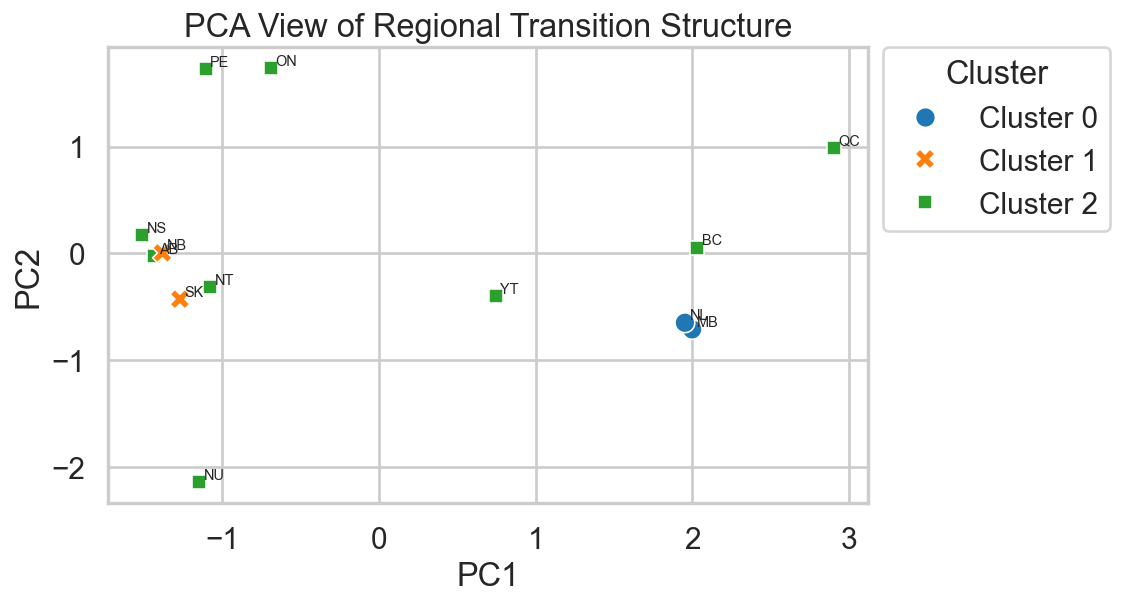

,PC1_loading,PC2_loading
renew_share_mean,0.597252,0.137009
fossil_share_mean,-0.597252,-0.137009
hhi_mean,0.411010,-0.439918
capacity_mean,0.279671,0.547627
renew_share_std,-0.198583,0.684861


In [12]:
pca_input = region_features[["renew_share_mean", "renew_share_std", "fossil_share_mean", "hhi_mean", "capacity_mean"]].copy()
scaler = StandardScaler()
Xp = scaler.fit_transform(pca_input)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(Xp)

pca_df = region_features[["Region", "Cluster", "ClusterLabel"]].copy() if "ClusterLabel" in region_features.columns else region_features[["Region", "Cluster"]].copy()
if "ClusterLabel" not in pca_df.columns:
    pca_df["ClusterLabel"] = "Cluster " + pca_df["Cluster"].astype(int).astype(str)
pca_df["PC1"] = components[:, 0]
pca_df["PC2"] = components[:, 1]

expl = pca.explained_variance_ratio_
print("Explained variance ratio:", expl)
print("Cumulative variance (2 PCs):", expl.sum())
cluster_order = sorted(
    pca_df["ClusterLabel"].astype(str).unique(),
    key=lambda s: int(s.split()[-1]) if s.split()[-1].isdigit() else 999,
)

plt.figure(figsize=(9, 5))
ax = sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="ClusterLabel",
    style="ClusterLabel",
    hue_order=cluster_order,
    style_order=cluster_order,
    palette="tab10",
    s=120,
)
for _, r in pca_df.iterrows():
    ax.text(r["PC1"] + 0.03, r["PC2"] + 0.03, r["Region"], fontsize=8)
ax.set_title("PCA View of Regional Transition Structure")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=["renew_share_mean", "renew_share_std", "fossil_share_mean", "hhi_mean", "capacity_mean"],
    columns=["PC1_loading", "PC2_loading"],
)
display(loadings.sort_values("PC1_loading", key=lambda s: s.abs(), ascending=False))

### Interpretation of Multivariate Structure
PCA captures dominant covariation across transition indicators, and loading magnitudes identify the strongest drivers of regional separation. This dimensionality reduction improves interpretation of structural regimes.

## 7. Forecasting: Region-Source Capacity Prediction (Temporal Validation)

Temporal validation evaluates model performance using strictly time-ordered train-test splits. For each split, the model is trained on earlier years and evaluated on subsequent years to assess out-of-time generalization and prevent look-ahead bias.

In [13]:
forecast_df = panel.copy().dropna(subset=["lag1", "lag2", "growth_yoy", "roll_mean_3", "roll_std_3", "renew_share", "hhi"]).copy()
base_feature_cols = ["lag1", "lag2", "growth_yoy", "roll_mean_3", "roll_std_3", "renew_share", "hhi"]

for c in base_feature_cols:
    forecast_df = forecast_df[np.isfinite(forecast_df[c])]

forecast_df = forecast_df.sort_values(["Year", "Region", "Source"]).reset_index(drop=True)
X_num = forecast_df[base_feature_cols]
X_cat = pd.get_dummies(forecast_df[["Region", "Source"]], drop_first=True)
X_all = pd.concat([X_num, X_cat], axis=1)
y_all = forecast_df["Data"]

def safe_mape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-6) -> float:
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-6) -> float:
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100

def by_source_metrics(block: pd.DataFrame) -> pd.DataFrame:
    out = block.groupby("Source").apply(
        lambda d: pd.Series({
            "MAE": mean_absolute_error(d["Data"], d["pred"]),
            "RMSE": mean_squared_error(d["Data"], d["pred"]) ** 0.5,
            "sMAPE": smape(d["Data"].to_numpy(), d["pred"].to_numpy()),
            "AE_p90": float(np.quantile(np.abs(d["Data"].to_numpy() - d["pred"].to_numpy()), 0.90)),
        }),
        include_groups=False,
    ).reset_index()
    return out

def evaluate_forecast_split(train_end: int) -> tuple[dict, pd.DataFrame]:
    train_idx = forecast_df["Year"] <= train_end
    test_idx = forecast_df["Year"] > train_end

    model = HistGradientBoostingRegressor(random_state=42)
    model.fit(X_all.loc[train_idx], y_all.loc[train_idx])
    pred = model.predict(X_all.loc[test_idx])

    test_block = forecast_df.loc[test_idx].copy()
    test_block["pred"] = pred
    y_true = test_block["Data"].to_numpy()
    err = pred - y_true
    ae = np.abs(err)

    split_metrics = {
        "train_end": train_end,
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "MAPE_nonzero": safe_mape(y_true, pred),
        "sMAPE": smape(y_true, pred),
        "BiasMean": float(np.mean(err)),
        "AE_p50": float(np.quantile(ae, 0.50)),
        "AE_p90": float(np.quantile(ae, 0.90)),
    }

    source_metrics = by_source_metrics(test_block)
    source_metrics["train_end"] = train_end
    return split_metrics, source_metrics

splits = [2011, 2012, 2013, 2014]
forecast_eval = []
source_eval = []
for train_end in splits:
    split_metrics, source_metrics = evaluate_forecast_split(train_end)
    forecast_eval.append(split_metrics)
    source_eval.append(source_metrics)

forecast_eval_df = pd.DataFrame(forecast_eval)
forecast_by_source_df = pd.concat(source_eval, ignore_index=True)

display(forecast_eval_df)
source_compact = forecast_by_source_df.groupby("Source", as_index=False)[["MAE", "RMSE", "sMAPE", "AE_p90"]].mean().sort_values("sMAPE", ascending=False)
display(source_compact.head(10))

uncertainty_snapshot = forecast_eval_df[["train_end", "AE_p50", "AE_p90", "BiasMean"]].copy()
display(uncertainty_snapshot)

,train_end,MAE,RMSE,MAPE_nonzero,sMAPE,BiasMean,AE_p50,AE_p90
0,2011,1566.819283,4371.004149,2223.932720,75.261567,541.537328,175.691621,3584.337741
1,2012,1206.712147,2956.362052,823.501286,61.357051,-95.870103,158.129588,3408.882167
2,2013,931.207739,2967.627129,2973.932597,68.170007,53.191683,124.627538,1282.324391
3,2014,832.241651,2801.658709,2400.393187,66.914566,-38.309407,118.379316,1461.715417


,Source,MAE,RMSE,sMAPE,AE_p90
6,Solar,331.219702,639.905003,155.965652,1119.059579
0,Biomass,252.832037,679.092838,72.698415,466.161436
1,Coal,1023.740422,1994.510369,67.509706,2693.935193
4,Nuclear,4308.424900,6413.163972,66.478524,11779.961346
2,Hydro,3249.075652,6257.997197,60.103706,9350.500548
5,Oil and Diesel,252.490574,718.138127,55.586950,470.834068
7,Wind,434.172685,898.579097,51.170922,1480.001261
3,Natural Gas,1319.253455,3436.868981,36.432602,1898.949123


,train_end,AE_p50,AE_p90,BiasMean
0,2011,175.691621,3584.337741,541.537328
1,2012,158.129588,3408.882167,-95.870103
2,2013,124.627538,1282.324391,53.191683
3,2014,118.379316,1461.715417,-38.309407


### Interpretation of Temporal Forecast Diagnostics
Forecast evaluation now reports average error, tail error, and bias, alongside source-level difficulty. Reliability is therefore assessed more comprehensively than with a single aggregate metric.

## 7A. Forecast Model Comparison and Uplift Analysis

This section compares three forecasting strategies under identical temporal splits: a persistence baseline (`NaiveLag1`), a linear model, and gradient boosting.

,Model,MAE,RMSE,sMAPE
2,NaiveLag1,134.364825,374.447895,9.203346
1,LinearRegression,179.935263,379.196865,54.208290
0,HistGradientBoosting,1134.245205,3274.163010,67.925798


,train_end,RMSE_uplift_pct_vs_naive
0,2011,-1026.766692
1,2012,-628.361636
2,2013,-624.194930
3,2014,-852.322922


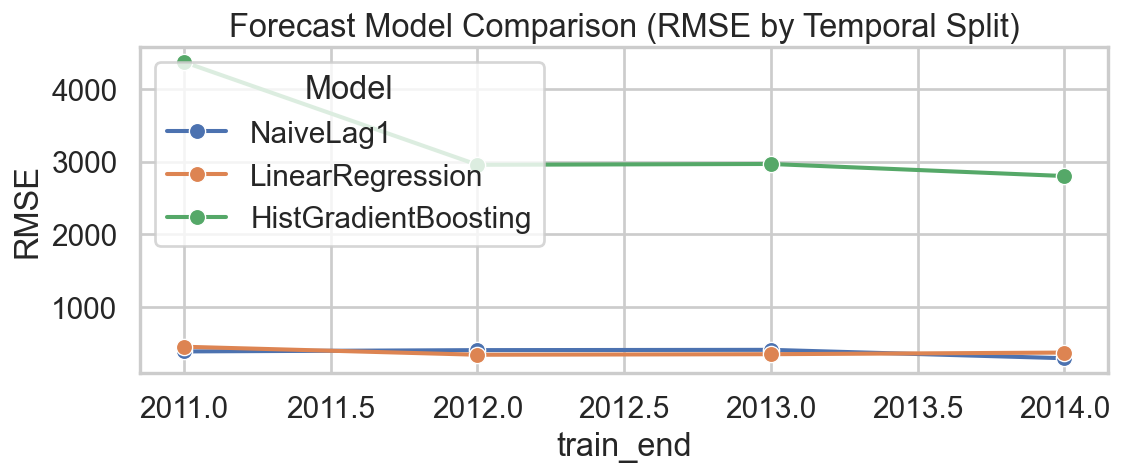

In [14]:
from sklearn.linear_model import LinearRegression

comp_rows = []
X_cmp = pd.concat([forecast_df[base_feature_cols], pd.get_dummies(forecast_df[["Region", "Source"]], drop_first=True)], axis=1)
y_cmp = forecast_df["Data"]

def model_predictions(train_idx: pd.Series, test_idx: pd.Series) -> dict[str, np.ndarray]:
    preds = {"NaiveLag1": forecast_df.loc[test_idx, "lag1"].to_numpy()}

    lin = LinearRegression()
    lin.fit(X_cmp.loc[train_idx], y_cmp.loc[train_idx])
    preds["LinearRegression"] = lin.predict(X_cmp.loc[test_idx])

    gbr = HistGradientBoostingRegressor(random_state=42)
    gbr.fit(X_cmp.loc[train_idx], y_cmp.loc[train_idx])
    preds["HistGradientBoosting"] = gbr.predict(X_cmp.loc[test_idx])
    return preds

for train_end in splits:
    train_idx = forecast_df["Year"] <= train_end
    test_idx = forecast_df["Year"] > train_end
    y_true = y_cmp.loc[test_idx].to_numpy()

    for model_name, pred_arr in model_predictions(train_idx, test_idx).items():
        comp_rows.append(
            {
                "train_end": train_end,
                "Model": model_name,
                "MAE": mean_absolute_error(y_true, pred_arr),
                "RMSE": mean_squared_error(y_true, pred_arr) ** 0.5,
                "sMAPE": smape(y_true, pred_arr),
            }
        )

forecast_model_comp_df = pd.DataFrame(comp_rows)
comp_avg = forecast_model_comp_df.groupby("Model", as_index=False)[["MAE", "RMSE", "sMAPE"]].mean().sort_values("RMSE")
display(comp_avg)

pivot_rmse = forecast_model_comp_df.pivot(index="train_end", columns="Model", values="RMSE")
uplift_df = pd.DataFrame()
if {"NaiveLag1", "HistGradientBoosting"}.issubset(pivot_rmse.columns):
    uplift = ((pivot_rmse["NaiveLag1"] - pivot_rmse["HistGradientBoosting"]) / pivot_rmse["NaiveLag1"]) * 100
    uplift_df = pd.DataFrame({"train_end": uplift.index, "RMSE_uplift_pct_vs_naive": uplift.values})
    display(uplift_df)

plt.figure(figsize=(9, 4))
sns.lineplot(data=forecast_model_comp_df, x="train_end", y="RMSE", hue="Model", marker="o")
plt.title("Forecast Model Comparison (RMSE by Temporal Split)")
plt.tight_layout()
plt.show()

### Interpretation of Forecast Model Uplift
Uplift relative to the naive persistence baseline is measured under leakage-controlled temporal splits. Reported gains therefore reflect genuine incremental predictive value rather than validation artifacts.

## 7B. Transition Stress-Test Simulation

A policy stress-test is performed by applying a +10 percentage-point renewable-share shock (bounded to [0,1]) and evaluating predicted transition-class shifts under fixed model structure.

,Region,BaselineClass,ScenarioClass,Changed
2,MB,Mature-Stable,Leader,True
3,NB,Lagging,Leader,True
5,NS,Emerging,Leader,True
6,NT,Emerging,Leader,True
0,AB,Emerging,Emerging,False
1,BC,Leader,Leader,False
4,NL,Mature-Stable,Mature-Stable,False
7,NU,Lagging,Lagging,False
8,ON,Leader,Leader,False
9,PE,Leader,Leader,False


,BaselineClass,ScenarioClass,size
4,Leader,Leader,4
2,Lagging,Lagging,2
1,Emerging,Leader,2
6,Mature-Stable,Mature-Stable,2
0,Emerging,Emerging,1
3,Lagging,Leader,1
5,Mature-Stable,Leader,1


ScenarioClass,Emerging,Lagging,Leader,Mature-Stable
BaselineClass,,,,
Emerging,1,0,2,0
Lagging,0,2,1,0
Leader,0,0,4,0
Mature-Stable,0,0,1,2


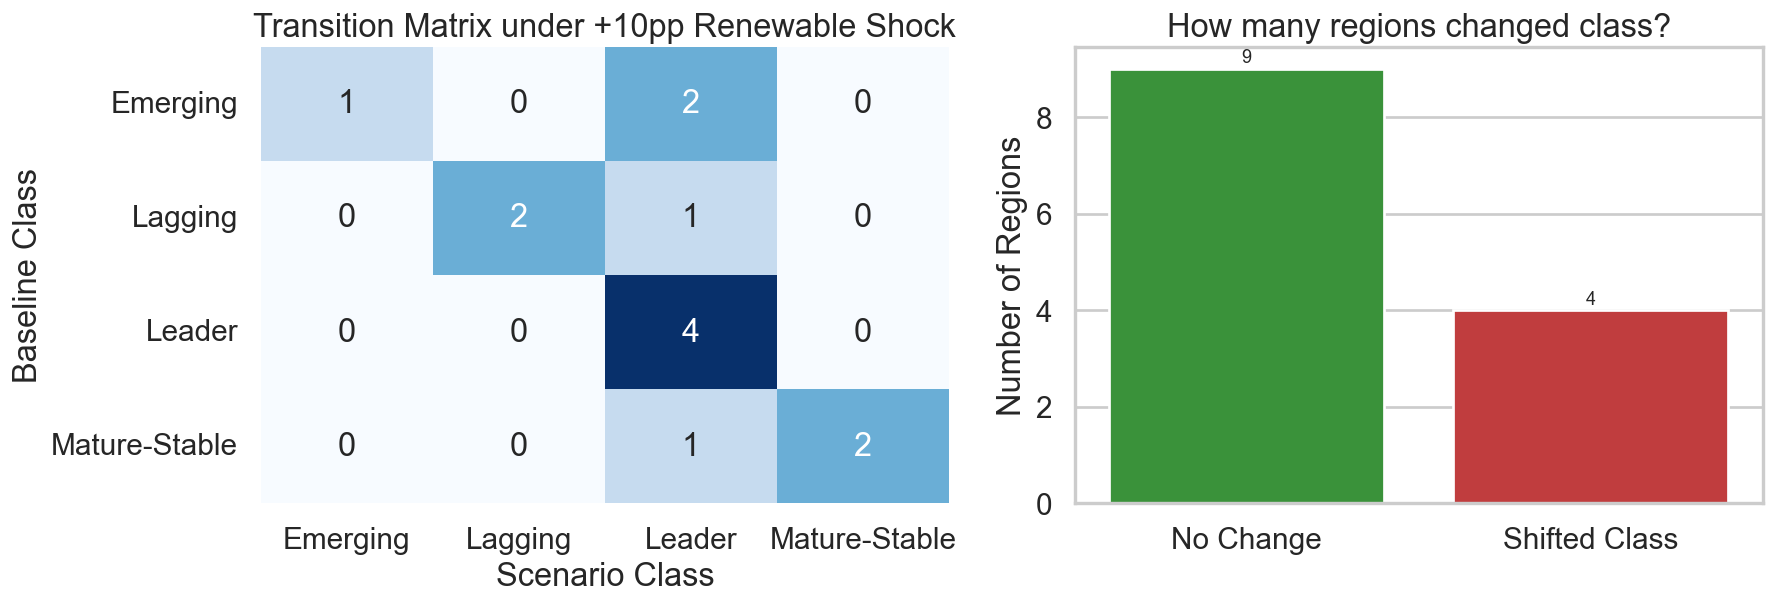

Number of regions changing predicted class: 4
Stress-test matrix exported to: /Users/margaretmangwende/Desktop/Machine learning project/output/dashboard_transition_stresstest_matrix.html


In [15]:
shock_pp = 0.10
latest_year_clf = int(clf_data["Year"].max())
baseline = clf_data[clf_data["Year"] == latest_year_clf].copy().reset_index(drop=True)
baseline_X = baseline[feature_cols_clf].copy()

scenario = baseline.copy()
scenario["renew_share"] = np.clip(scenario["renew_share"] + shock_pp, 0.0, 1.0)
scenario["renew_momentum"] = scenario["renew_momentum"] + shock_pp
scenario["hhi"] = np.clip(scenario["hhi"] * 0.97, 0.0, 1.0)
scenario_X = scenario[feature_cols_clf].copy()

baseline_pred = rf.predict(baseline_X)
scenario_pred = rf.predict(scenario_X)

scenario_shift_df = pd.DataFrame({
    "Region": baseline["Region"],
    "BaselineClass": baseline_pred,
    "ScenarioClass": scenario_pred,
})
scenario_shift_df["Changed"] = scenario_shift_df["BaselineClass"] != scenario_shift_df["ScenarioClass"]

transition_counts = scenario_shift_df.groupby(["BaselineClass", "ScenarioClass"], as_index=False).size()
display(scenario_shift_df.sort_values(["Changed", "Region"], ascending=[False, True]))
display(transition_counts.sort_values("size", ascending=False))

# Replace Sankey with clearer transition matrix + impact bars
class_order = sorted(set(scenario_shift_df["BaselineClass"]).union(set(scenario_shift_df["ScenarioClass"])))
shift_matrix = pd.crosstab(
    scenario_shift_df["BaselineClass"],
    scenario_shift_df["ScenarioClass"],
    dropna=False,
).reindex(index=class_order, columns=class_order, fill_value=0)
display(shift_matrix)

impact_counts = (
    scenario_shift_df.assign(Outcome=np.where(scenario_shift_df["Changed"], "Shifted Class", "No Change"))
    .groupby("Outcome", as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(shift_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title(f"Transition Matrix under +{int(shock_pp*100)}pp Renewable Shock")
axes[0].set_xlabel("Scenario Class")
axes[0].set_ylabel("Baseline Class")

color_map = {"Shifted Class": "#d62728", "No Change": "#2ca02c"}
impact_sorted = impact_counts.sort_values("Count", ascending=False).copy()
sns.barplot(
    data=impact_sorted,
    x="Outcome",
    y="Count",
    hue="Outcome",
    palette=color_map,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("How many regions changed class?")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Regions")
for p in axes[1].patches:
    h = p.get_height()
    axes[1].text(p.get_x() + p.get_width() / 2, h + 0.05, f"{int(h)}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Keep one interactive export, but make it directly interpretable (matrix heatmap)
heatmap_df = shift_matrix.reset_index().melt(id_vars="BaselineClass", var_name="ScenarioClass", value_name="Count")
fig_shift = px.density_heatmap(
    heatmap_df,
    x="ScenarioClass",
    y="BaselineClass",
    z="Count",
    color_continuous_scale="Blues",
    title=f"Transition Matrix Under +{int(shock_pp*100)}pp Renewable Share Shock",
    text_auto=True,
)
display(fig_shift)
fig_shift.write_html(str(OUT_DIR / "dashboard_transition_stresstest_matrix.html"), include_plotlyjs="cdn")

print("Number of regions changing predicted class:", int(scenario_shift_df["Changed"].sum()))
print("Stress-test matrix exported to:", OUT_DIR / "dashboard_transition_stresstest_matrix.html")

### Interpretation of Stress-Test Results
The stress-test quantifies transition-class shifts under a renewable-share shock. This counterfactual evidence strengthens policy relevance beyond descriptive trend reporting.

## 8. Interactive Dashboard Outputs

This section exports interactive visual artifacts for transparent analytical inspection and interpretation.

In [16]:
plotly_template = "plotly_white"
latest_year = int(region_mix["Year"].max())

fig1_df = canada.copy()
fig1 = px.area(
    fig1_df,
    x="Year",
    y="Data",
    color="Source",
    title="Canada Capacity Composition by Source",
    template=plotly_template,
    labels={"Data": "Capacity (MW)"},
)
fig1.update_layout(hovermode="x unified", legend_title_text="Source")
display(fig1)
fig1.write_html(str(OUT_DIR / "dashboard_capacity_composition.html"), include_plotlyjs="cdn")

fig3_df = region_features.copy()
if "ClusterLabel" not in fig3_df.columns:
    fig3_df["ClusterLabel"] = "Cluster " + fig3_df["Cluster"].astype(int).astype(str)
fig3 = px.scatter(
    fig3_df,
    x="renew_share_mean",
    y="hhi_mean",
    color="ClusterLabel",
    size="capacity_mean",
    hover_name="Region",
    title="Regional Clusters: Renewable Share vs Concentration (HHI)",
    template=plotly_template,
    labels={
        "renew_share_mean": "Renewable Share (Mean)",
        "hhi_mean": "Concentration (HHI)",
        "ClusterLabel": "Cluster",
    },
)
fig3.update_layout(hovermode="closest")
display(fig3)
fig3.write_html(str(OUT_DIR / "dashboard_cluster_scatter.html"), include_plotlyjs="cdn")

if "label_df" in globals() and isinstance(label_df, pd.DataFrame) and not label_df.empty:
    transition_counts = label_df["TransitionLabel"].value_counts().rename_axis("TransitionLabel").reset_index(name="Count")
    fig4 = px.bar(
        transition_counts,
        x="TransitionLabel",
        y="Count",
        title="Transition Label Distribution",
        template=plotly_template,
        labels={"Count": "Number of Regions"},
    )
    display(fig4)
    fig4.write_html(str(OUT_DIR / "dashboard_transition_labels.html"), include_plotlyjs="cdn")

if "priority_table" in globals() and isinstance(priority_table, pd.DataFrame) and not priority_table.empty:
    pr = priority_table.sort_values("PriorityScore", ascending=False).copy()
    fig5 = px.bar(
        pr,
        x="Region",
        y="PriorityScore",
        color="Priority",
        title="Policy Priority Score by Region",
        template=plotly_template,
    )
    display(fig5)
    fig5.write_html(str(OUT_DIR / "dashboard_priority_score.html"), include_plotlyjs="cdn")

if "scenario_shift_df" in globals() and isinstance(scenario_shift_df, pd.DataFrame) and not scenario_shift_df.empty:
    impact = scenario_shift_df[scenario_shift_df["Region"] != "Canada"].copy()
    impact["Changed"] = impact["Changed"].astype(str).str.lower().isin(["true", "1", "yes"])
    impact_counts = impact.groupby("Changed", as_index=False).size()
    impact_counts["Outcome"] = impact_counts["Changed"].map({True: "Shifted Class", False: "No Change"})
    fig6 = px.bar(
        impact_counts,
        x="Outcome",
        y="size",
        title="Stress-Test Impact Counts",
        template=plotly_template,
        labels={"size": "Number of Regions"},
    )
    display(fig6)
    fig6.write_html(str(OUT_DIR / "dashboard_stresstest_impact.html"), include_plotlyjs="cdn")

print("Interactive dashboard files saved:")
for name in [
    "dashboard_capacity_composition.html",
    "dashboard_cluster_scatter.html",
    "dashboard_transition_labels.html",
    "dashboard_priority_score.html",
    "dashboard_stresstest_impact.html",
    "dashboard_transition_stresstest_matrix.html",
]:
    path = OUT_DIR / name
    if path.exists():
        print("-", path)

Interactive dashboard files saved:
- /Users/margaretmangwende/Desktop/Machine learning project/output/dashboard_capacity_composition.html
- /Users/margaretmangwende/Desktop/Machine learning project/output/dashboard_cluster_scatter.html
- /Users/margaretmangwende/Desktop/Machine learning project/output/dashboard_transition_labels.html
- /Users/margaretmangwende/Desktop/Machine learning project/output/dashboard_stresstest_impact.html
- /Users/margaretmangwende/Desktop/Machine learning project/output/dashboard_transition_stresstest_matrix.html


## 8A. Integrated Interactive Dashboard (Notebook)

This section provides a consolidated in-notebook dashboard view to complement the exported HTML artifacts and external application interface.

In [17]:
from plotly.subplots import make_subplots

dashboard_fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=(
        "1) National Capacity Trend",
        f"2) Renewable vs Non-renewable Composition ({latest_year})",
        "3) Clustered Regional Structure",
        "4) Priority Score by Region",
        "5) Transition Score (Priority Colors)",
        "6) Stress-Test Impact",
    ),
    specs=[
        [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
    ],
)

def add_panel_annotation(axis_num: int, text: str, y: float = 0.5, size: int = 12):
    dashboard_fig.add_annotation(
        x=0.5,
        y=y,
        xref=f"x{axis_num} domain",
        yref=f"y{axis_num} domain",
        text=text,
        showarrow=False,
        font=dict(size=size),
    )

def load_priority_panel() -> tuple[pd.DataFrame | None, float, float]:
    panel_df, high_q, mid_q = None, np.nan, np.nan
    if (
        "label_df" in globals()
        and isinstance(label_df, pd.DataFrame)
        and not label_df.empty
        and "region_features" in globals()
        and isinstance(region_features, pd.DataFrame)
        and not region_features.empty
    ):
        panel_df, high_q, mid_q = build_priority_table(label_df, region_features)
    else:
        path_priority = OUT_DIR / "nb_priority_table.csv"
        if path_priority.exists():
            tmp_priority = pd.read_csv(path_priority)
            if {"Region", "PriorityScore"}.issubset(tmp_priority.columns):
                panel_df = tmp_priority.copy()
                high_q = float(panel_df["PriorityScore"].quantile(2 / 3))
                mid_q = float(panel_df["PriorityScore"].quantile(1 / 3))
                if "Priority" not in panel_df.columns:
                    panel_df["Priority"] = np.select(
                        [
                            panel_df["PriorityScore"] >= high_q,
                            panel_df["PriorityScore"] >= mid_q,
                        ],
                        ["High", "Medium"],
                        default="Low",
                    )
                if (
                    "TransitionScore" not in panel_df.columns
                    and {"renew_end", "renew_delta"}.issubset(panel_df.columns)
                ):
                    panel_df["TransitionScore"] = (
                        0.55 * panel_df["renew_end"].rank(pct=True)
                        + 0.45 * panel_df["renew_delta"].rank(pct=True)
                    ) * 100.0
    return panel_df, high_q, mid_q

can_tot = canada.groupby("Year", as_index=False)["Data"].sum()
year_span = f"{int(df['Year'].min())}-{int(df['Year'].max())}"
run_stamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")

dashboard_fig.add_trace(
    go.Scatter(
        x=can_tot["Year"],
        y=can_tot["Data"],
        mode="lines+markers",
        name="Canada Total Capacity",
    ),
    row=1,
    col=1,
)

latest_rank_panel = (
    region_mix[region_mix["Year"] == latest_year]
    .sort_values("renew_share", ascending=False)
    .copy()
)
latest_rank_panel["non_renew_share"] = 1.0 - latest_rank_panel["renew_share"]

dashboard_fig.add_trace(
    go.Bar(
        x=latest_rank_panel["Region"],
        y=latest_rank_panel["renew_share"],
        name="Renewable Share",
    ),
    row=1,
    col=2,
)
dashboard_fig.add_trace(
    go.Bar(
        x=latest_rank_panel["Region"],
        y=latest_rank_panel["non_renew_share"],
        name="Non-renewable Share",
    ),
    row=1,
    col=2,
)

cluster_panel_df = region_features.copy()
if "ClusterLabel" not in cluster_panel_df.columns:
    cluster_panel_df["ClusterLabel"] = "Cluster " + cluster_panel_df["Cluster"].astype(int).astype(str)

cluster_order = sorted(
    cluster_panel_df["ClusterLabel"].astype(str).unique(),
    key=lambda s: int(s.split()[-1]) if s.split()[-1].isdigit() else 999,
)
for label in cluster_order:
    block = cluster_panel_df[cluster_panel_df["ClusterLabel"] == label]
    dashboard_fig.add_trace(
        go.Scatter(
            x=block["renew_share_mean"],
            y=block["hhi_mean"],
            mode="markers+text",
            text=block["Region"],
            textposition="top center",
            name=label,
        ),
        row=1,
        col=3,
    )

priority_panel_df, q_high, q_mid = load_priority_panel()
priority_color_map = {"High": "#d62728", "Medium": "#ff7f0e", "Low": "#2ca02c"}

if isinstance(priority_panel_df, pd.DataFrame) and not priority_panel_df.empty:
    score_legend = pd.DataFrame(
        [
            [
                "TransitionScore",
                "0.55*rank(renew_end) + 0.45*rank(renew_delta)",
                "Higher = stronger transition progress",
                "Displayed in panel 5",
            ],
            [
                "PriorityScore",
                "0.60*(1-TransitionScore) + 0.25*rank(fossil) + 0.15*rank(capacity)",
                "Higher = more urgent policy priority",
                "Displayed in panel 4",
            ],
            [
                "Color code",
                "PriorityScore terciles",
                "High=Red, Medium=Orange, Low=Green",
                f"Cutoffs: High ≥ {q_high:.1f}, Medium ≥ {q_mid:.1f}, Low < {q_mid:.1f}",
            ],
        ],
        columns=["Item", "How computed", "Interpretation", "Visual meaning"],
    )
    display(score_legend)

    ps = priority_panel_df.sort_values("PriorityScore", ascending=False).copy()
    dashboard_fig.add_trace(
        go.Bar(
            x=ps["Region"],
            y=ps["PriorityScore"],
            marker_color=ps["Priority"].map(priority_color_map),
            customdata=np.stack(
                [ps["Priority"], ps.get("TransitionScore", pd.Series([np.nan] * len(ps)))],
                axis=1,
            ),
            hovertemplate="Region=%{x}<br>PriorityScore=%{y:.1f}<br>Priority=%{customdata[0]}<br>TransitionScore=%{customdata[1]:.1f}<extra></extra>",
            name="Priority Score",
        ),
        row=2,
        col=1,
    )
else:
    add_panel_annotation(4, "Run Sections 5-7 to generate policy-priority evidence.")

if (
    isinstance(priority_panel_df, pd.DataFrame)
    and not priority_panel_df.empty
    and {"Region", "TransitionScore"}.issubset(priority_panel_df.columns)
):
    transition_plot = priority_panel_df.sort_values("TransitionScore", ascending=False).copy()
    dashboard_fig.add_trace(
        go.Bar(
            x=transition_plot["Region"],
            y=transition_plot["TransitionScore"],
            marker_color=transition_plot.get("Priority", pd.Series(["Medium"] * len(transition_plot))).map(priority_color_map),
            customdata=np.stack([transition_plot["PriorityScore"], transition_plot["Priority"]], axis=1),
            hovertemplate="Region=%{x}<br>TransitionScore=%{y:.1f}<br>PriorityScore=%{customdata[0]:.1f}<br>Priority=%{customdata[1]}<extra></extra>",
            name="Transition Score",
        ),
        row=2,
        col=2,
    )
    add_panel_annotation(
        5,
        "Color rule: High priority (red) = top PriorityScore tercile; Medium (orange); Low (green)",
        y=-0.25,
        size=11,
    )
else:
    add_panel_annotation(5, "Run Section 6 to generate transition groups.")

shift_panel_df = None
if "scenario_shift_df" in globals() and isinstance(scenario_shift_df, pd.DataFrame) and not scenario_shift_df.empty:
    shift_panel_df = scenario_shift_df.copy()
else:
    path_shift = OUT_DIR / "nb_transition_stresstest_shifts.csv"
    if path_shift.exists():
        shift_panel_df = pd.read_csv(path_shift)

if (
    isinstance(shift_panel_df, pd.DataFrame)
    and not shift_panel_df.empty
    and {"Region", "Changed"}.issubset(shift_panel_df.columns)
):
    shift_panel_df = shift_panel_df[shift_panel_df["Region"] != "Canada"].copy()
    shift_panel_df["Changed"] = shift_panel_df["Changed"].astype(str).str.lower().isin(["true", "1", "yes"])
    impact = shift_panel_df.groupby("Changed", as_index=False).size()
    impact["Outcome"] = impact["Changed"].map({True: "Shifted Class", False: "No Change"})
    dashboard_fig.add_trace(
        go.Bar(
            x=impact["Outcome"],
            y=impact["size"],
            marker_color=impact["Outcome"].map({
                "Shifted Class": "#d62728",
                "No Change": "#2ca02c",
            }),
            name="Number of Regions",
        ),
        row=2,
        col=3,
    )
else:
    add_panel_annotation(6, "Run Section 7B to generate stress-test impact.")

dashboard_fig.update_layout(barmode="group")
dashboard_fig.update_yaxes(tickformat=".0%", row=1, col=2)
dashboard_fig.update_xaxes(title_text="Year", row=1, col=1)
dashboard_fig.update_yaxes(title_text="Capacity (MW)", row=1, col=1)
dashboard_fig.update_xaxes(title_text="Region", row=1, col=2)
dashboard_fig.update_yaxes(title_text="Share", row=1, col=2)
dashboard_fig.update_xaxes(title_text="Renewable Share (Mean)", row=1, col=3)
dashboard_fig.update_yaxes(title_text="Concentration (HHI)", row=1, col=3)
dashboard_fig.update_xaxes(title_text="Region", row=2, col=1)
dashboard_fig.update_yaxes(title_text="Priority Score", row=2, col=1)
dashboard_fig.update_xaxes(title_text="Region", row=2, col=2)
dashboard_fig.update_yaxes(title_text="Transition Score", row=2, col=2)
dashboard_fig.update_xaxes(title_text="Outcome", row=2, col=3)
dashboard_fig.update_yaxes(title_text="Number of Regions", row=2, col=3)

dashboard_fig.update_layout(
    template="plotly_white",
    height=980,
    width=1500,
    title_text=f"Integrated Analytical Dashboard: Canadian Electricity Transition ({year_span})",
    legend_title_text="Series",
)

dashboard_fig.add_annotation(
    x=0.0,
    y=1.16,
    xref="paper",
    yref="paper",
    xanchor="left",
    showarrow=False,
    align="left",
    font=dict(size=11, color="#4a4a4a"),
    text=(
        f"Data years: {year_span} | Latest dashboard year: {latest_year} | Refreshed: {run_stamp}<br>"
        "Decision notes: PriorityScore guides intervention urgency; TransitionScore reflects progress; results are associative, not causal."
    ),
)

display(dashboard_fig)
dashboard_fig.write_html(str(OUT_DIR / "dashboard_notebook_integrated.html"), include_plotlyjs="cdn")
print("Integrated notebook dashboard saved:", OUT_DIR / "dashboard_notebook_integrated.html")

,Item,How computed,Interpretation,Visual meaning
0,TransitionScore,0.55*rank(renew_end) + 0.45*rank(renew_delta),Higher = stronger transition progress,Displayed in panel 5
1,PriorityScore,0.60*(1-TransitionScore) + 0.25*rank(fossil) +...,Higher = more urgent policy priority,Displayed in panel 4
2,Color code,PriorityScore terciles,"High=Red, Medium=Orange, Low=Green","Cutoffs: High ≥ 49.5, Medium ≥ 38.9, Low < 38.9"


Integrated notebook dashboard saved: /Users/margaretmangwende/Desktop/Machine learning project/output/dashboard_notebook_integrated.html


### Interpretation of Integrated Dashboard Evidence
The top row summarizes system trajectory and structure, while the bottom row translates outputs into priority, transition, and stress-test action panels. The interface supports rapid policy interpretation while keeping score semantics explicit (TransitionScore = progress, PriorityScore = urgency, colors = priority tiers).

### Model Risk and Limitations (Operational Use)
- Results are **associative** and predictive, not causal policy-effect estimates.
- Structural breaks (extreme hydro shocks, fuel price disruptions, and policy regime shifts) can reduce forecast stability.
- Small class counts and class imbalance can inflate apparent performance for dominant classes.
- Priority and transition scores are **decision-support indicators** and should be combined with domain constraints (grid reliability, cost, permitting, and interties).
- Recommended governance: periodic retraining, drift checks on source-level error, and annual threshold review for priority tiers.

## 9. Discussion, Conclusions, and Recommendations

### Discussion
- The empirical results indicate pronounced regional heterogeneity in transition pathways, supporting geographically differentiated policy design rather than uniform national assumptions (Markard, Raven and Truffer, 2012; Sovacool, 2016).
- Cluster and classification outputs align with evidence that transition systems often exhibit non-linear regime behavior, making comparative model benchmarking necessary for defensible inference (Breiman, 2001).
- Temporal forecast diagnostics reported in both absolute and percentage terms support transparent planning interpretation under uncertainty, consistent with established forecast-accuracy guidance (Hyndman and Koehler, 2006).

### Conclusions
- The integrated ML pipeline provides a coherent framework for regional transition profiling and capacity forecasting.
- Unsupervised segmentation, supervised classification, and temporal forecasting collectively improve interpretability and policy relevance.
- The analytical outputs provide a defensible basis for prioritizing interventions in lagging or high-fossil regions.

### Policy Recommendations
1. Prioritize clean capacity deployment in regions with persistent fossil dependence and weaker transition classification outcomes.
2. Incorporate diversification and resilience indicators into medium-term planning frameworks.
3. Institutionalize periodic model retraining and dashboard-based monitoring for evidence-informed decision cycles.

### References
Breiman, L. (2001) ‘Random Forests’, Machine Learning, 45(1), pp. 5–32.
Canada Energy Regulator (2024) Canada’s Energy Future 2023: Executive Summary. Available at: https://www.cer-rec.gc.ca/ (Accessed: 27 February 2026).
Hyndman, R.J. and Koehler, A.B. (2006) ‘Another look at measures of forecast accuracy’, International Journal of Forecasting, 22(4), pp. 679–688.
International Energy Agency (2022) Canada 2022 Energy Policy Review. Paris: International Energy Agency.
Markard, J., Raven, R. and Truffer, B. (2012) ‘Sustainability transitions: An emerging field of research and its prospects’, Research Policy, 41(6), pp. 955–967.
Sovacool, B.K. (2016) ‘How long will it take? Conceptualizing the temporal dynamics of energy transitions’, Energy Research & Social Science, 13, pp. 202–215.
Statistics Canada (2024) Hydroelectricity generation dries up amid low precipitation and record high temperatures: Electricity year in review 2023. Available at: https://www.statcan.gc.ca/ (Accessed: 27 February 2026).

## 10. Results Export

In [18]:
priority_table, q_high, q_mid = build_priority_table(label_df, region_features)

quality_table.to_csv(OUT_DIR / "nb_quality_checks.csv", index=False)
source_summary.to_csv(OUT_DIR / "nb_source_summary.csv", index=False)
if "cluster_method_df" in globals():
    cluster_method_df.to_csv(OUT_DIR / "nb_cluster_method_scan.csv", index=False)
region_features.to_csv(OUT_DIR / "nb_region_features_clusters.csv", index=False)
label_df.to_csv(OUT_DIR / "nb_transition_labels.csv", index=False)
forecast_eval_df.to_csv(OUT_DIR / "nb_forecast_eval.csv", index=False)
if "forecast_by_source_df" in globals():
    forecast_by_source_df.to_csv(OUT_DIR / "nb_forecast_by_source_eval.csv", index=False)
if "forecast_model_comp_df" in globals():
    forecast_model_comp_df.to_csv(OUT_DIR / "nb_forecast_model_comparison.csv", index=False)
if "scenario_shift_df" in globals():
    scenario_shift_df.to_csv(OUT_DIR / "nb_transition_stresstest_shifts.csv", index=False)
priority_table.to_csv(OUT_DIR / "nb_priority_table.csv", index=False)

clf_acc_mean = np.nan
clf_f1_mean = np.nan
if "benchmark_df" in globals() and isinstance(benchmark_df, pd.DataFrame) and not benchmark_df.empty:
    ok_bench = benchmark_df[benchmark_df["Status"] == "ok"]
    if not ok_bench.empty:
        clf_acc_mean = float(ok_bench.iloc[0]["Accuracy_mean"])
        clf_f1_mean = float(ok_bench.iloc[0]["F1_macro_mean"])
run_meta = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "random_seed": 42,
    "rows_used": int(df.shape[0]),
    "regions": int(df["Region"].nunique()),
    "sources": int(df["Source"].nunique()),
    "years": int(df["Year"].nunique()),
    "best_cluster_k": int(best_k),
    "classification_acc_groupcv_mean": clf_acc_mean,
    "classification_f1_groupcv_mean": clf_f1_mean,
    "forecast_mae_mean": float(forecast_eval_df["MAE"].mean()),
}
with open(OUT_DIR / "nb_run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_meta, f, indent=2)

display(priority_table[["Region", "TransitionLabel", "Cluster", "Priority", "PriorityScore"]])
print("Export completed. Output directory:", OUT_DIR)

,Region,TransitionLabel,Cluster,Priority,PriorityScore
7,NU,Lagging,2,High,81.5
0,AB,Emerging,2,High,75.0
11,SK,Lagging,1,High,72.2
3,NB,Lagging,1,High,62.8
5,NS,Emerging,2,High,49.5
4,NL,Mature-Stable,0,Medium,48.5
8,ON,Leader,2,Medium,46.5
6,NT,Emerging,2,Medium,40.9
2,MB,Mature-Stable,0,Medium,38.9
10,QC,Mature-Stable,2,Low,33.5


Export completed. Output directory: /Users/margaretmangwende/Desktop/Machine learning project/output
